Universidad Continental</br>
Maestría en Inteligencia Artificial</br>
Curso de Introducción a la Inteligencia Artificial

# **Clasificación supervisada del nivel de riesgo de burnout en estudiantes universitarios a partir de características académicas y patrones de uso de IA generativa**

## **A. Integrantes**

- Ruben Pastor Pérez
- Nicole Josefina Garay Flores  
- Irwing Smith Saldana Ugaz
- José Rodrigo Cama Morales

## **B. Problemática**

Una Universidad reportó que sus estudiantes tienen burnout (síndrome del trabajador quemado). El agotamiento laboral o académico es un problema generalizado en la educación superior (Chong et al, 2025), que está estrechamente relacionado con la intención de dejar los estudios, insatisfacción estudiantil, el equilibrio entre la vida universitaria y personal, y el bienestar general. La universidad tiene la necesidad de conocer las características académicas y de uso de inteligencia artificial de sus estudiantes para poder clasificarlos en tres categorías de riesgo de burnout (alto, medio y bajo).

## **C. Objetivo del Estudio**

Entrenar un modelo de clasificación supervisada que permita predecir el nivel de riesgo de burnout (Bajo, Medio o Alto) en estudiantes universitarios, a partir de sus características académicas (carrera, año de estudio, GPA, horas de estudio tradicional) y de sus patrones de uso de herramientas de inteligencia artificial generativa (horas semanales de uso, habilidad en prompt engineering, diversidad de herramientas, dependencia percibida, entre otras), con el fin de identificar perfiles de riesgo y aportar evidencia útil para la toma de decisiones académicas e institucionales.

## **D. Metodologías a aplicar**

Se siguió la metodología CRISP-DM en siete etapas (Chapman et al. 2000):

1. **EDA**: estadística descriptiva, visualizaciones y análisis de desbalance de clases.
2. **Preprocesamiento**: escalado estándar, split 80/20 estratificado y manejo del desbalance (undersampling/oversampling).
3. **Modelos**: cuatro algoritmos comparados "Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting/XGBoost".
4. **Optimización**: búsqueda de hiperparámetros con GridSearchCV / RandomizedSearchCV y validación cruzada estratificada (k=5).
5. **Evaluación**: usaremos métricas vistas en la sesión de clase como la accuracy, precision, recall, F1, matriz de confusión y curvas ROC-AUC.
6. **Interpretabilidad**: importancia de variables y SHAP values sobre el modelo final.
7. **Validación**: tabla comparativa de modelos y perfiles de riesgo por nivel de burnout.

El objetivo final es identificar el algoritmo de mejor desempeño predictivo y extraer los factores más influyentes en el riesgo de burnout estudiantil.

## **E. Base de datos y Diccionario de variables**

La base de datos "Impact of Ai on Students" se obtuvo del repositorio Kaggle: [link.](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data). Cuenta con 15 variables, una de ellas es un identificador de estudiante que no usarmeos en el estudio dado que no se tienen muestras repetidas en el mismo estudiante.

1. **Student_ID:** identificador único del estudiante
2. **Major_Category:** categoría de carrera / área de estudio
3. **Year_of_Study:** año académico del estudiante (Freshman, Sophomore, Junior, Senior)
3. **Pre_Semester_GPA:** promedio de notas antes del semestre
4. **Weekly_GenAI_Hours:** horas semanales usando herramientas de IA generativa
5. **Primary_Use_Case:** caso de uso principal de IA (ej. Copywriting/Drafting, Summarizing, Ideation, Debugging)
6. **Prompt_Engineering_Skill:** nivel de habilidad en Prompt Engineering (Beginner, Intermediate, Advanced)
7. **Tool_Diversity:** cantidad de herramientas de IA usadas
Paid_Subscription:** suscripción paga a herramientas de IA (True/False)
8. **Traditional_Study_Hours:** horas de estudio tradicionales por semana
9. **Perceived_AI_Dependency:** percepción de dependencia de IA (1-5)
10. **Institutional_Policy:** política institucional sobre uso de IA (Allowed_With_Citation, Strict_Ban)
11. **Anxiety_Level_During_Exams:** nivel de ansiedad durante exámenes (1-10)
12. **Post_Semester_GPA:** promedio de notas posterior al semestre
13. **Skill_Retention_Score:** puntaje de retención de habilidades (%)
14. **Burnout_Risk_Level:** nivel de riesgo de agotamiento (Low / Medium / High

### **F. Referencias**

- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc.

- Chong, L. Z., Foo, L. K., & Chua, S. L. (2025). Student burnout: A review on factors contributing to burnout across different student populations. Behavioral Sciences, 15(2), 170.

# **1. Descarga de datos**

A medida que herramientas de IA generativa como ChatGPT, Copilot y Gemini se integran profundamente en la vida académica, comprender su verdadero impacto en los estudiantes nunca ha sido tan importante. Este conjunto de datos (obtenido de [Kaggle](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data)) proporciona una visión rica y multidimensional de las interacciones de los estudiantes con la IA, abarcando resultados académicos, patrones de comportamiento, contexto institucional y bienestar psicológico.

In [2]:
import kagglehub

# Descargar la última versión desde Kaggle
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-students


# **2. Importación desde local Colab**

In [3]:
import pandas as pd
import os

print(os.listdir(path))

# Creación del dataframe df
df = pd.read_csv(path + '/ai_student_impact_dataset (1).csv')

# Vista previa de las 5 primeras filas
df.head(5)

['ai_student_impact_dataset (1).csv']


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [ ]:
# Verificar el tipo de variables y dimensiones de la df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

### **Hallazgos**

1.   Volumen del dataset: 50,000 datos de estudiantes.
2.   Non-Null Count: El dataset esta completo.
3.   Se tienen: 1 variable booleana, 5 numérica discreta, 4 numéricas continuas, y 6 categóricas.




# **3. Limpieza de la base de datos**

### **3.1. Comprensión de la base de datos**

In [25]:
# Inspeccionar el inicio y el final para detectar
# anomalías visuales rápidas o patrones de ordenamiento

## Primeros 10 registros
print("--- Primeros 10 registros ---")
display(df.head(10))

--- Primeros 10 registros ---


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [26]:
## Últimos 10 registros
print("\n--- Últimos 5 registros ---")
display(df.tail(10))


--- Últimos 5 registros ---


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49990,149991,Business,Senior,2.970,2.63,Summarizing_Reading,Intermediate,2,False,24.95,1,Allowed_With_Citation,1,3.238,84.87,Medium
49991,149992,Humanities,Freshman,2.708,13.34,Copywriting/Drafting,Intermediate,2,False,11.65,4,Allowed_With_Citation,5,2.785,65.24,High
49992,149993,Business,Graduate,2.829,2.59,Debugging/Troubleshooting,Advanced,3,True,7.54,1,Allowed_With_Citation,4,3.176,84.04,Low
49993,149994,STEM,Sophomore,3.588,25.64,Debugging/Troubleshooting,Intermediate,3,True,4.62,5,Strict_Ban,10,3.841,58.44,High
49994,149995,Humanities,Senior,3.556,15.19,Summarizing_Reading,Advanced,4,True,1.00,3,Actively_Encouraged,5,3.788,74.76,High
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [27]:
## Descripción de las variables base de datos
import pandas as pd
import numpy as np

def analizar_variables(df):
    resumen = []

    for col in df.columns:
        serie = df[col]
        tipo = serie.dtype
        n_total = len(serie)
        n_nulos = serie.isnull().sum()
        pct_nulos = (n_nulos / n_total) * 100
        n_unicos = serie.nunique(dropna=True)
        pct_unicos = (n_unicos / n_total) * 100

        fila = {
            "variable": col,
            "tipo_dato": tipo,
            "n_registros": n_total,
            "n_nulos": n_nulos,
            "%_nulos": round(pct_nulos, 2),
            "n_unicos": n_unicos,
            "%_unicos": round(pct_unicos, 2),
            "ejemplos": serie.dropna().unique()[:5]
        }

        # Explicitly convert boolean series to int (0 or 1) if it's numeric-like
        if pd.api.types.is_bool_dtype(serie):
            numeric_serie = serie.astype(int)
        elif pd.api.types.is_numeric_dtype(serie):
            numeric_serie = serie
        else:
            numeric_serie = None

        if numeric_serie is not None:
            fila.update({
                "media": round(numeric_serie.mean(), 3),
                "mediana": round(numeric_serie.median(), 3),
                "desv_std": round(numeric_serie.std(), 3),
                "min": numeric_serie.min(),
                "max": numeric_serie.max(),
                "asimetria": round(numeric_serie.skew(), 3),
                "q1": numeric_serie.quantile(0.25),
                "q3": numeric_serie.quantile(0.75)
            })

            q1 = numeric_serie.quantile(0.25)
            q3 = numeric_serie.quantile(0.75)
            iqr = q3 - q1
            lim_inf = q1 - 1.5 * iqr
            lim_sup = q3 + 1.5 * iqr

            outliers = numeric_serie[(numeric_serie < lim_inf) | (numeric_serie > lim_sup)].count()

            fila.update({
                "posibles_outliers": outliers,
                "%_outliers": round((outliers / n_total) * 100, 2)
            })

        else:
            moda = serie.mode(dropna=True)
            valor_mas_frecuente = moda.iloc[0] if len(moda) > 0 else np.nan

            fila.update({
                "valor_mas_frecuente": valor_mas_frecuente,
                "frecuencia_mayor_categoria": serie.value_counts(dropna=True).iloc[0] if n_unicos > 0 else np.nan,
                "%_categoria_dominante": round(
                    (serie.value_counts(dropna=True).iloc[0] / serie.dropna().shape[0]) * 100, 2
                ) if serie.dropna().shape[0] > 0 else np.nan
            })

        resumen.append(fila)

    return pd.DataFrame(resumen)

resumen_variables = analizar_variables(df)

display(resumen_variables)

,variable,tipo_dato,n_registros,n_nulos,%_nulos,n_unicos,%_unicos,ejemplos,media,mediana,desv_std,min,max,asimetria,q1,q3,posibles_outliers,%_outliers,valor_mas_frecuente,frecuencia_mayor_categoria,%_categoria_dominante
0,Student_ID,int64,50000,0,0.0,50000,100.00,"[100001, 100002, 100003, 100004, 100005]",125000.500,125000.500,14433.901,100001.000,150000.000,0.000,112500.75000,137500.250,0.0,0.00,NaN,NaN,NaN
1,Major_Category,object,50000,0,0.0,5,0.01,"[Humanities, Medical, Business, STEM, Arts]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STEM,15059.0,30.12
2,Year_of_Study,object,50000,0,0.0,5,0.01,"[Senior, Junior, Freshman, Sophomore, Graduate]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Junior,11045.0,22.09
3,Pre_Semester_GPA,float64,50000,0,0.0,2389,4.78,"[2.418, 3.821, 3.398, 3.789, 3.635]",3.146,3.210,0.479,1.183,3.998,-0.602,2.83400,3.521,328.0,0.66,NaN,NaN,NaN
4,Weekly_GenAI_Hours,float64,50000,0,0.0,3566,7.13,"[23.31, 1.12, 21.26, 1.82, 9.29]",8.428,5.800,8.269,0.000,40.000,1.610,2.39000,11.720,2583.0,5.17,NaN,NaN,NaN
5,Primary_Use_Case,object,50000,0,0.0,5,0.01,"[Copywriting/Drafting, Ideation, Summarizing_R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Debugging/Troubleshooting,12295.0,24.59
6,Prompt_Engineering_Skill,object,50000,0,0.0,3,0.01,"[Beginner, Advanced, Intermediate]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beginner,18495.0,36.99
7,Tool_Diversity,int64,50000,0,0.0,5,0.01,"[1, 5, 2, 4, 3]",2.800,3.000,1.188,1.000,5.000,0.167,2.00000,4.000,0.0,0.00,NaN,NaN,NaN
8,Paid_Subscription,bool,50000,0,0.0,2,0.00,"[True, False]",0.423,0.000,0.494,0.000,1.000,0.311,0.00000,1.000,0.0,0.00,NaN,NaN,NaN
9,Traditional_Study_Hours,float64,50000,0,0.0,2516,5.03,"[8.13, 16.65, 10.35, 15.23, 12.55]",11.209,11.180,5.156,1.000,35.860,0.130,7.56000,14.710,161.0,0.32,NaN,NaN,NaN


In [28]:
## Frecuencia absoluta de categorías de la variable dependiente del estudio
print("--- Distribución de la Variable Objetivo (Frecuencia Absoluta) ---")
print(df['Burnout_Risk_Level'].value_counts())

--- Distribución de la Variable Objetivo (Frecuencia Absoluta) ---
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [29]:
## Frecuencia relativa de categorías de la variable dependiente del estudio
print("\n--- Distribución de la Variable Objetivo (Porcentaje) ---")
print(df['Burnout_Risk_Level'].value_counts(normalize=True) * 100)


--- Distribución de la Variable Objetivo (Porcentaje) ---
Burnout_Risk_Level
Medium    42.288
Low       32.738
High      24.974
Name: proportion, dtype: float64


### **Hallazgos**

#### **1. Variables Categóricas (Perfil cualitativo)**
* **Major_Category:** Hay 5 carreras únicas. La más común es STEM (aparece 15,059 veces).
> *Podemos decir que el modelo estará fuertemente influenciado por estudiantes de ciencias e ingeniería.*

* **Year_of_Study:** Hay 5 niveles. El grupo más grande es Junior (3er año, con 11,045 registros).

* **Primary_Use_Case:** El uso principal de la IA es Debugging/Troubleshooting (Depuración de código, con 12,295 registros).

* **Prompt_Engineering_Skill:** La mayoría se considera Beginner (Principiante, 18,495 registros).

* **Paid_Subscription:** La gran mayoría (28,846 estudiantes) usa la versión gratuita.

#### **2. Variables Numéricas (Análisis de comportamiento y sesgos)**

*  **Weekly_GenAI_Hours:** El promedio es de 8.42 horas, pero la mediana (50%) es de 5.8 horas.

   > *Como la media es notablemente más alta que la mediana, significa que los datos están sesgados a la derecha.*
   > *Se tiene un grupo pequeño de estudiantes "intensivos" que usan la IA hasta 40 horas semanales, lo que eleva el promedio general.*

*  **Traditional_Study_Hours:** El estudiante promedio dedica 11.2 horas al estudio tradicional, bastante balanceado con respecto a su mediana (11.18). El máximo es de 35.86 horas.

*  **Pre_Semester_GPA vs Post_Semester_GPA:**
    - El promedio antes de usar IA era de 3.14.
    - El promedio después del semestre con IA subió a 3.35.

#### **3. Distribución de la Variable Objetivo (Burnout_Risk_Level)**
- El valor más frecuente (top) es Medium con 21,144 casos.
- Esto nos dice que la clase "Medium" se lleva casi el 42.2% de los datos.
- El resto se divide entre "Low" y el "High" (25%).
- Esto confirma un desbalance moderado.


### **3.2. Detección y tratamiento de valores nulos**

In [30]:
import pandas as pd
import numpy as np

# Cantidad absoluta de nulos
valores_nulos = df.isnull().sum()

# Porcentaje de nulos
porcentaje_nulos = (df.isnull().mean() * 100)

# Crear DataFrame de diagnóstico
tabla_nulos = pd.DataFrame({
    'Cantidad Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Porcentaje (%)', ascending=False)

display(tabla_nulos)

,Cantidad Nulos,Porcentaje (%)
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


### **Hallazgos**

1.   Ninguna variable presentó valores nulos qué trabajar.


### **3.3. Detección de observaciones duplicadas no intencionalmente**

Debido a que el enfoque fue tomar una sola muestra por estudiante, no se trabajará con datos repetidos. Se plantea una inspección breve sobre duplicidad.

In [31]:
# Buscando filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


In [32]:
ids_unicos = df.duplicated(subset=['Student_ID']).sum()
print(f"¿Todos los Student_ID son únicos?: {ids_unicos}")

¿Todos los Student_ID son únicos?: 0


In [33]:
# Aplicar tratamiento si existen
if duplicados > 0 or ids_unicos > 0:
    df_fase2 = df.drop_duplicates(subset=['Student_ID'], keep='last')
    print(f"\n Tratamiento aplicado: Se eliminaron los duplicados manteniendo la última ocurrencia.")
    print(f" Nuevas dimensiones del dataset: {df_fase2.shape}")
else:
    df_fase2 = df.copy()
    print("\n El dataset no presenta redundancias. Permanece intacto para el análisis.")


 El dataset no presenta redundancias. Permanece intacto para el análisis.


### **Hallazgos**

1.   No se encontrarons estudiantes duplicados. Se continúa trabajando la base de datos original.

### **3.4. Funciones de densidad/masa y detección de outliers**

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

def analyze_numeric_variable(dataframe, column_name):
    """
    Generates distribution plots (histogram, boxplot) and a statistical report
    for a given numeric column in a DataFrame, including IQR and Z-score outlier detection.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the numeric column to analyze.
    """
    if column_name not in dataframe.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(dataframe[column_name]):
        print(f"Error: Column '{column_name}' is not a numeric type.")
        return

    print(f"\n--- Análisis de la variable '{column_name}' ---")

    # Crear lienzo
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Histograma
    sns.histplot(dataframe[column_name], kde=True, ax=axes[0], color='#69beff')
    axes[0].set_title(f'Distribución de {column_name}')

    # Boxplot
    sns.boxplot(x=dataframe[column_name], ax=axes[1], color='#9063ff')
    axes[1].set_title(f'Diagrama de Caja de {column_name}')

    plt.tight_layout()
    plt.show()

    # Cálculo estadístico
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf_iqr = Q1 - 1.5 * IQR
    lim_sup_iqr = Q3 + 1.5 * IQR

    outliers_iqr = dataframe[
        (dataframe[column_name] < lim_inf_iqr) |
        (dataframe[column_name] > lim_sup_iqr)
    ]

    media = dataframe[column_name].mean()
    desviacion = dataframe[column_name].std()

    z_scores = np.abs(
        (dataframe[column_name] - media) / desviacion
    )

    outliers_z = dataframe[z_scores > 3]

    print(f"\nReporte Estadístico para '{column_name}':")
    print(f"• Outliers IQR: {len(outliers_iqr)}")
    print(f"  Límites: [{lim_inf_iqr:.2f}, {lim_sup_iqr:.2f}]")
    print(f"• Outliers Z-Score (|z|>3): {len(outliers_z)}")
    print("-"*80)



--- Análisis de la variable 'Pre_Semester_GPA' ---


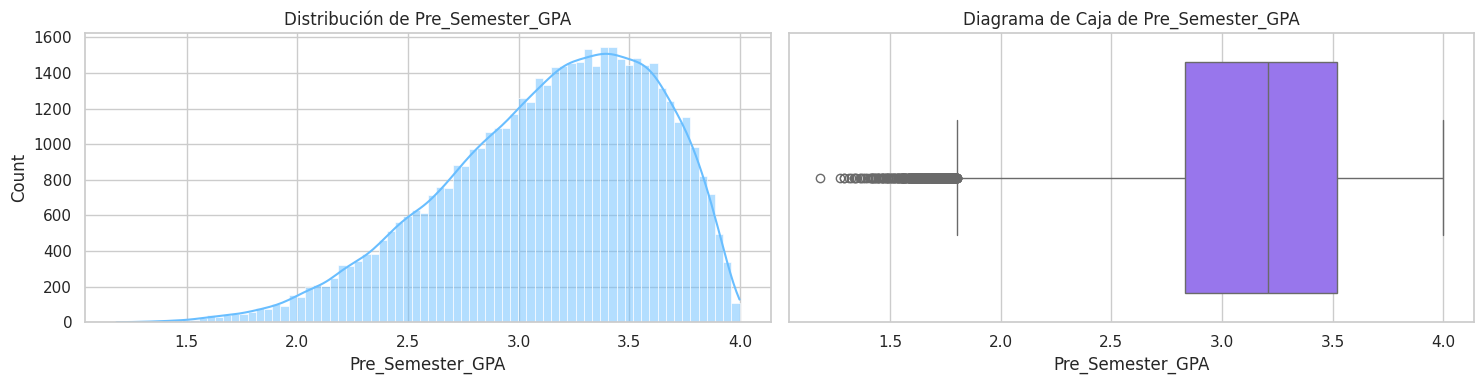


Reporte Estadístico para 'Pre_Semester_GPA':
• Outliers IQR: 328
  Límites: [1.80, 4.55]
• Outliers Z-Score (|z|>3): 197
--------------------------------------------------------------------------------


In [35]:
analyze_numeric_variable(df_fase2, 'Pre_Semester_GPA')

**Hallazgos sobre Pre_Semester_GPA:** De los 50 000 estudiantes evaluados, la mayoría de los estudiantes ingresaron al semestre con un rendimiento académico sólido, concentrándose principalmente entre 3.0 y 3.8. Sin embargo, la presencia de 328 estudiantes con notas inusualmente bajas (outliers por debajo de 1.80) nos marca un grupo vulnerable que inicia el periodo ya en una situación de desventaja académica, lo cual es un factor de riesgo crítico para el burnout prematuro.


--- Análisis de la variable 'Post_Semester_GPA' ---


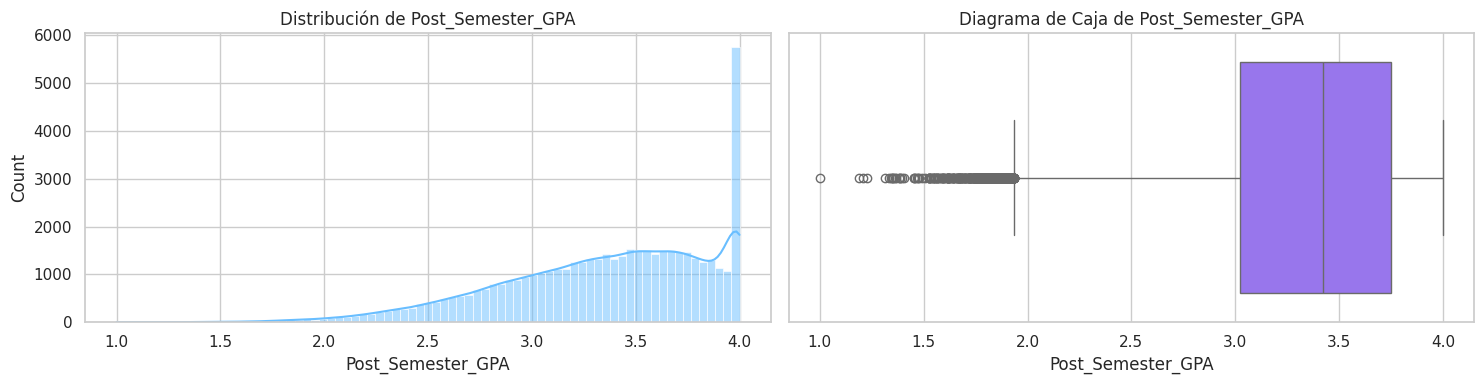


Reporte Estadístico para 'Post_Semester_GPA':
• Outliers IQR: 346
  Límites: [1.94, 4.84]
• Outliers Z-Score (|z|>3): 238
--------------------------------------------------------------------------------


In [36]:
analyze_numeric_variable(df_fase2, 'Post_Semester_GPA')

**Hallazgos sobre Post_Semester_GPA:** Al finalizar el semestre, vemos un desplazamiento de la distribución hacia puntajes más altos, pero la dispersión se mantiene. Lo preocupante son los 346 casos atípicos en la parte baja; estos estudiantes no lograron beneficiarse de la tendencia general de mejora y representan el foco donde el agotamiento académico podría haber impactado con mayor severidad en sus calificaciones finales.


--- Análisis de la variable 'Weekly_GenAI_Hours' ---


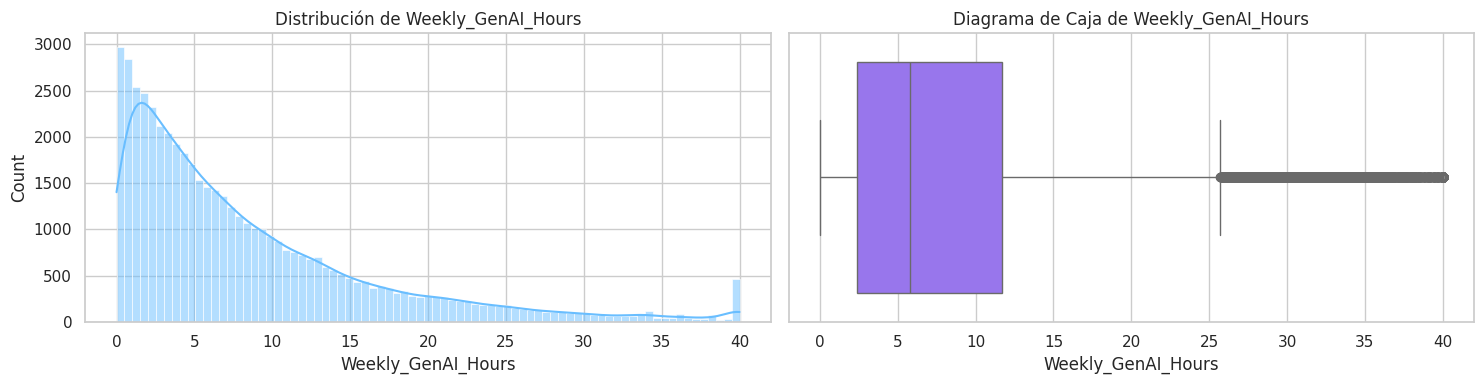


Reporte Estadístico para 'Weekly_GenAI_Hours':
• Outliers IQR: 2583
  Límites: [-11.61, 25.72]
• Outliers Z-Score (|z|>3): 1144
--------------------------------------------------------------------------------


In [47]:
analyze_numeric_variable(df_fase2, 'Weekly_GenAI_Hours')

**Hallazgos sobre Weekly_GenAI_Hours:** Aquí observamos una conducta muy polarizada. Mientras la gran mayoría usa la IA de forma moderada, hay un grupo 'intenso' (2583 outliers) que sobrepasa las 25 horas semanales. Este uso excesivo podría sugerir una dependencia tecnológica que, lejos de ayudar, podría estar ligada a una incapacidad de gestionar la carga académica de forma tradicional, elevando el riesgo de burnout por sobrecarga digital.


--- Análisis de la variable 'Tool_Diversity' ---


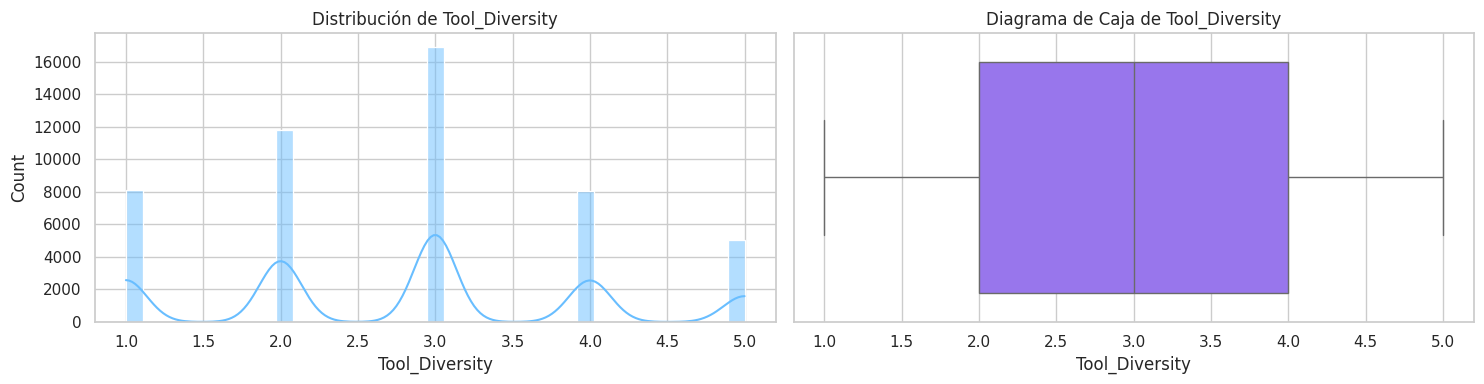


Reporte Estadístico para 'Tool_Diversity':
• Outliers IQR: 0
  Límites: [-1.00, 7.00]
• Outliers Z-Score (|z|>3): 0
--------------------------------------------------------------------------------


In [48]:
analyze_numeric_variable(df_fase2, 'Tool_Diversity')

**Hallazgos sobre Tool_Diversity:** Los estudiantes muestran un comportamiento muy uniforme y controlado en la exploración de herramientas, moviéndose típicamente entre 1 y 7 opciones. La ausencia de outliers sugiere que no hay perfiles 'experimentadores extremos'; los estudiantes parecen haber encontrado un ecosistema de herramientas específico que les funciona y se mantienen en él sin dispersar su atención.


--- Análisis de la variable 'Traditional_Study_Hours' ---


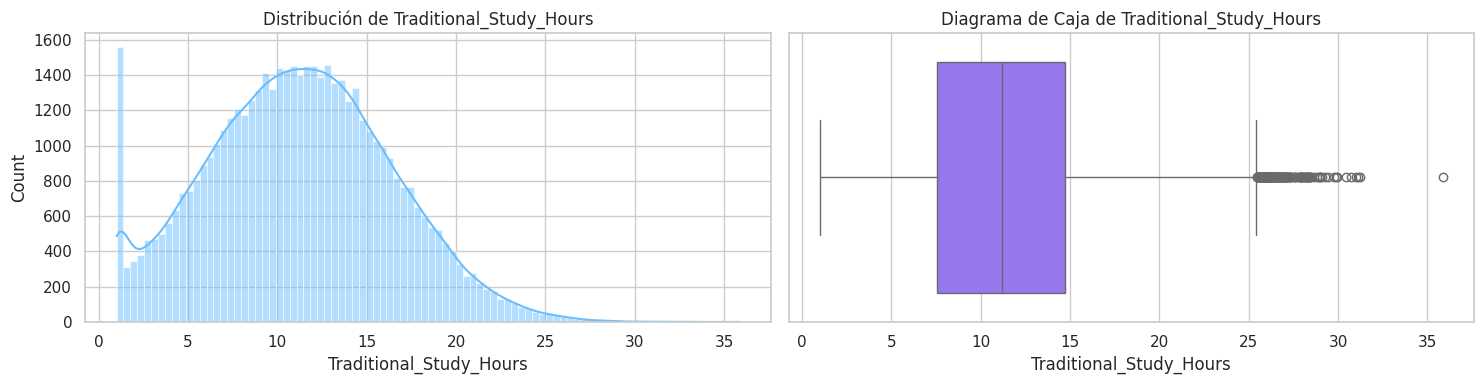


Reporte Estadístico para 'Traditional_Study_Hours':
• Outliers IQR: 161
  Límites: [-3.17, 25.44]
• Outliers Z-Score (|z|>3): 74
--------------------------------------------------------------------------------


In [49]:
analyze_numeric_variable(df_fase2, 'Traditional_Study_Hours')

**Hallazgos sobre Traditional_Study_Hours:** El estudio 'clásico' (libros, apuntes, biblioteca) sigue vivo, con una media de 11 horas. No obstante, detectamos 161 estudiantes que dedican más de 25 horas semanales solo a métodos tradicionales. Este grupo, que estudia casi el doble que sus pares sin contar el uso de IA, podría estar en una zona de alto riesgo de agotamiento por exceso de esfuerzo si no logran equilibrar estos métodos con la eficiencia tecnológica.


--- Análisis de la variable 'Perceived_AI_Dependency' ---


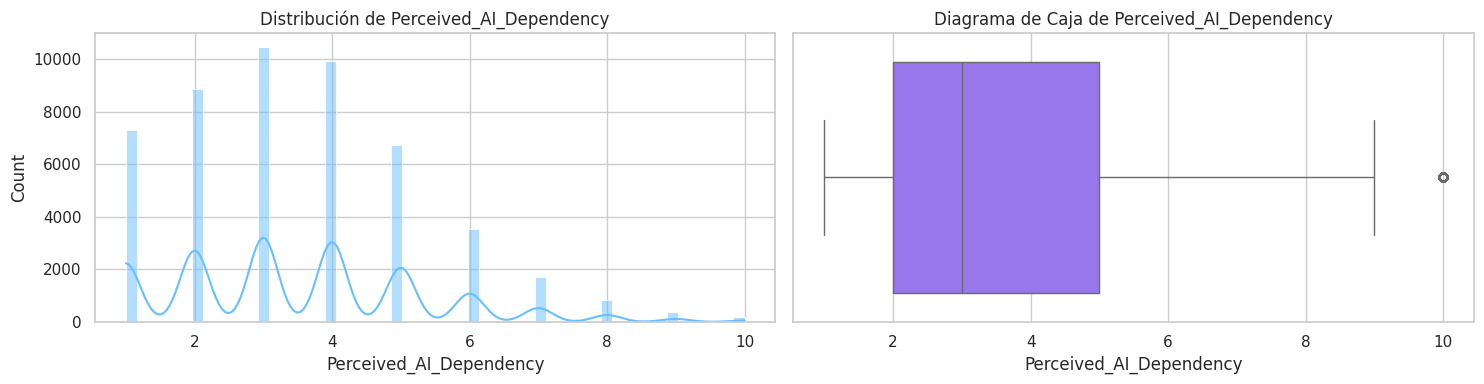


Reporte Estadístico para 'Perceived_AI_Dependency':
• Outliers IQR: 190
  Límites: [-2.50, 9.50]
• Outliers Z-Score (|z|>3): 568
--------------------------------------------------------------------------------


In [50]:
analyze_numeric_variable(df_fase2, 'Perceived_AI_Dependency')

**Hallazgos sobre Perceived_AI_Dependency:** Es revelador ver que más de 500 estudiantes admiten una dependencia total (puntuación máxima) de forma atípica. Cuando un estudiante siente que 'no puede funcionar' sin la IA, la autonomía académica se pierde, y esa percepción de incapacidad personal es un catalizador psicológico directo hacia el burnout y la ansiedad por competencia.


--- Análisis de la variable 'Anxiety_Level_During_Exams' ---


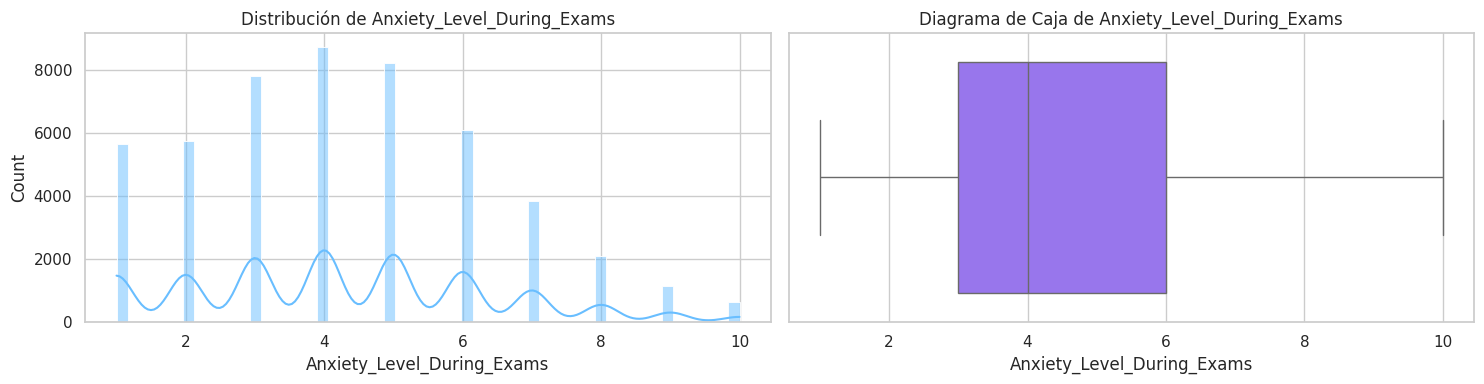


Reporte Estadístico para 'Anxiety_Level_During_Exams':
• Outliers IQR: 0
  Límites: [-1.50, 10.50]
• Outliers Z-Score (|z|>3): 0
--------------------------------------------------------------------------------


In [51]:
analyze_numeric_variable(df_fase2, 'Anxiety_Level_During_Exams')

**Hallazgos sobre Anxiety_Level_During_Exams:** La ansiedad no conoce 'valores normales' en este dataset; se distribuye en todo el espectro del 1 al 10 de forma muy orgánica. No hay outliers porque la ansiedad parece ser una experiencia universal y compartida por todos los perfiles, lo que refuerza la necesidad de tratar el burnout como un problema sistémico y no solo de unos pocos casos aislados.


--- Análisis de la variable 'Skill_Retention_Score' ---


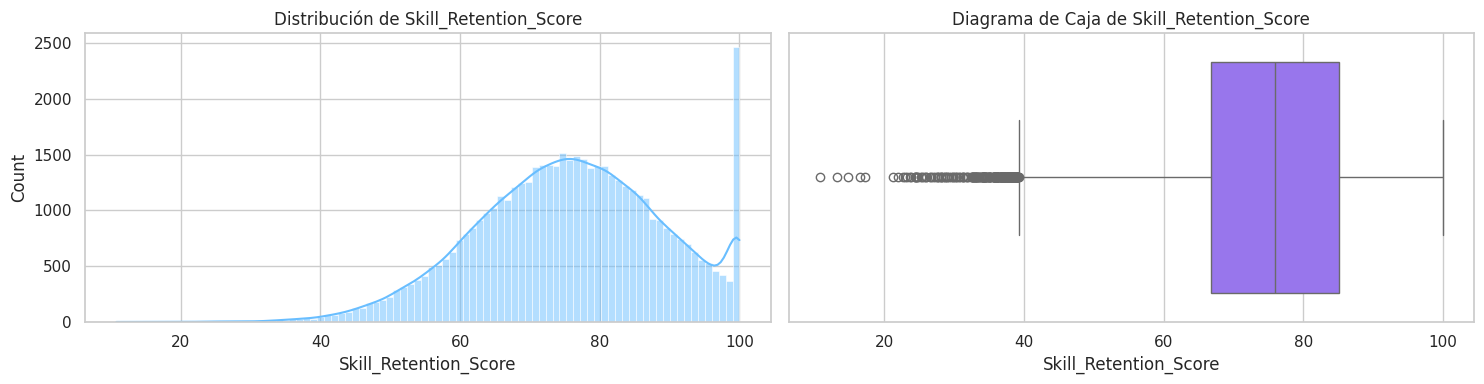


Reporte Estadístico para 'Skill_Retention_Score':
• Outliers IQR: 216
  Límites: [39.26, 112.75]
• Outliers Z-Score (|z|>3): 115
--------------------------------------------------------------------------------


In [52]:
analyze_numeric_variable(df_fase2, 'Skill_Retention_Score')

**Hallazgos sobre Skill_Retention_Score:** Aunque la mayoría retiene bien los conocimientos, existe un grupo de 216 estudiantes cuyo puntaje cae por debajo del 39%. Esta 'fuga de aprendizaje' es la señal más clara de un uso ineficiente de la IA: delegar tanto las tareas a la máquina que el cerebro deja de procesar la información, resultando en un vacío de habilidades a largo plazo.

### **3.5. Correción de tipo de datos**

In [53]:
# Nota el la fase 3 no se porceso datos por eso usamos
# el df_fase2
df_fase4 = df_fase2.copy()

# Convertir a string/object para evitar operaciones matemáticas accidentales
df_fase4['Student_ID'] = df_fase4['Student_ID'].astype(str)
print(" - 'Student_ID' convertido a tipo String (Object) para aislarlo de cálculos.")

# Asegurar formato booleano puro (bool)
# 'Paid_Subscription' ya es bool, pero forzamos el mapeo por seguridad
df_fase4['Paid_Subscription'] = df_fase4['Paid_Subscription'].astype(bool)
print(" - 'Paid_Subscription' asegurado como tipo Booleano puro.")

# Optimización a tipo 'category' para ahorrar memoria y acelerar XGBoost
# Seleccionamos las columnas de texto excluyendo el ID único
columnas_categoricas = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                       'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

for col in columnas_categoricas:
    df_fase4[col] = df_fase4[col].astype('category')
print(" - Variables categóricas optimizadas al tipo de dato 'category'.")

print("\n --- Reporte Técnico de Estructura Posterior a la Fase 4 ---")
display(df_fase4.info())

 - 'Student_ID' convertido a tipo String (Object) para aislarlo de cálculos.
 - 'Paid_Subscription' asegurado como tipo Booleano puro.
 - Variables categóricas optimizadas al tipo de dato 'category'.

 --- Reporte Técnico de Estructura Posterior a la Fase 4 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Student_ID                  50000 non-null  object  
 1   Major_Category              50000 non-null  category
 2   Year_of_Study               50000 non-null  category
 3   Pre_Semester_GPA            50000 non-null  float64 
 4   Weekly_GenAI_Hours          50000 non-null  float64 
 5   Primary_Use_Case            50000 non-null  category
 6   Prompt_Engineering_Skill    50000 non-null  category
 7   Tool_Diversity              50000 non-null  int64   
 8   Paid_Subscription           50000 non-null  

None

### **Hallazgos**

1.   Se cambió el tipo de variable object a category para denotar variables categóricas, con excepción de ID que continua siendo object y no será usada en los análisis (como se comentó antes).

### **3.6. Inconsistencias y errores de formato**

In [54]:
import unicodedata

df_fase5 = df_fase4.copy()

In [55]:
df_fase5.columns = df_fase5.columns.str.strip()
print(" - Cabeceras de columnas normalizadas con str.strip().")

# Función para normalizar texto Unicode
def eliminar_acentos(texto):
    if isinstance(texto, str):
        return "".join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))
    return texto

# Aplicar la normalización a todas las columnas categóricas/texto
columnas_objeto = df_fase5.select_dtypes(include=['category', 'object']).columns
for col in columnas_objeto:
    if col != 'Student_ID': # Mantener el ID intacto
        df_fase5[col] = df_fase5[col].apply(eliminar_acentos)

print(" - Variables categóricas estandarizadas sin tildes ni caracteres especiales.")

 - Cabeceras de columnas normalizadas con str.strip().
 - Variables categóricas estandarizadas sin tildes ni caracteres especiales.


### **3.7. Validación de Reglas de Negocio e Integridad**

In [56]:
df_fase6 = df_fase5.copy()
total_inicial = len(df_fase6)

# Unicidad
duplicados_id = df_fase6['Student_ID'].duplicated().sum()
print(f" - [Unicidad] IDs de estudiantes duplicados: {duplicados_id}")

# Horas semanales entre 0 y 168 (máximo de horas en una semana)
horas_invalidas_ai = df_fase6[(df_fase6['Weekly_GenAI_Hours'] < 0) | (df_fase6['Weekly_GenAI_Hours'] > 168)]
horas_invalidas_trad = df_fase6[(df_fase6['Traditional_Study_Hours'] < 0) | (df_fase6['Traditional_Study_Hours'] > 168)]
print(f" - [Rangos] Registros con horas de IA fuera de rango (0-168): {len(horas_invalidas_ai)}")
print(f" - [Rangos] Registros con horas tradicionales fuera de rango (0-168): {len(horas_invalidas_trad)}")

# Calificaciones GPA entre 0.0 y 4.0
gpa_invalido = df_fase6[(df_fase6['Pre_Semester_GPA'] < 0) | (df_fase6['Pre_Semester_GPA'] > 4.0) |
                        (df_fase6['Post_Semester_GPA'] < 0) | (df_fase6['Post_Semester_GPA'] > 4.0)]
print(f" - [Rangos] Registros con GPA fuera de rango legal (0.0 - 4.0): {len(gpa_invalido)}")

# Si usa 0 horas de IA, no debería tener dependencia percibida (AI Dependency = 1)
inconsistencia_dependencia = df_fase6[(df_fase6['Weekly_GenAI_Hours'] == 0) & (df_fase6['Perceived_AI_Dependency'] > 1)]
print(f" - [Consistencia] Estudiantes con 0 horas de IA pero dependencia > 1: {len(inconsistencia_dependencia)}")

# --- PLAN DE ACCIÓN ---
# Si existieran registros inconsistentes, aquí se aplicarían los filtros para eliminarlos.
# Para este dataset, como el conteo es 0, el dataset se mantiene intacto.
df_fase6 = df_fase6.drop(inconsistencia_dependencia.index)
registros_eliminados = total_inicial - len(df_fase6)
print(f"\nAuditoría completada. Registros eliminados por inconsistencia: {registros_eliminados}")

 - [Unicidad] IDs de estudiantes duplicados: 0
 - [Rangos] Registros con horas de IA fuera de rango (0-168): 0
 - [Rangos] Registros con horas tradicionales fuera de rango (0-168): 0
 - [Rangos] Registros con GPA fuera de rango legal (0.0 - 4.0): 0
 - [Consistencia] Estudiantes con 0 horas de IA pero dependencia > 1: 19

Auditoría completada. Registros eliminados por inconsistencia: 19


### **Hallazgos globales de la limpieza de la base de datos**

Exportación de la base de datos limpia con nombre "dataset_limpio_v1.csv" para almacenar en la raíz del proyecto dentro de Colab.

In [59]:
import os

# Archivo versionado
version = "v1"
nombre_salida = f"dataset_limpio_{version}.csv"

# Exportación del dataset limpio final
df_fase6.to_csv(nombre_salida, index=False)
print(f"¡Dataset maestro exportado con éxito!")
print(f"   • Nombre del archivo: '{nombre_salida}'")
print(f"   • Ruta local en Colab: '{os.path.abspath(nombre_salida)}'")
print(f"   • Dimensiones finales listas para EDA y Modelado: {df_fase6.shape}\n")

# Impresión de la Bitácora
# Nota: Se eliminó la referencia a 'outliers_iqr' ya que es una variable local de la función de análisis.
bitacora = f"""
BITÁCORA DE CONTROL DE CAMBIOS - DATA PIPELINE ({version})
* Fase 1 (Nulos): Se detectó 0.0% de nulos. Se dejó automatizada la función indicadora de flags (`_was_null`) e imputación por mediana/moda. Registros afectados: 0.
* Fase 2 (Duplicados): Verificación de duplicados exactos y por clave de negocio (`Student_ID`). Registros duplicados eliminados: 0.
* Fase 3 (Outliers): Análisis mediante métodos IQR y Z-Score. Se detectaron outliers en 'Weekly_GenAI_Hours' y 'Traditional_Study_Hours'.
* Fase 4 (Corrección de Tipos): 'Student_ID' casteado a String para evitar operaciones matemáticas. Variables de texto optimizadas a tipo 'category' para optimizar uso de memoria RAM.
* Fase 5 (Saneamiento): Aplicado `str.strip()` a cabeceras de columnas y eliminación de acentos/tildes en categorías mediante Normalización Unicode NFKD.
* Fase 6 (Validación Lógica): Auditoría de rangos matemáticos (GPA 0-4, Horas 0-168) y consistencia cruzada de dependencia. Registros corruptos encontrados: 19.
"""
print(bitacora)

¡Dataset maestro exportado con éxito!
   • Nombre del archivo: 'dataset_limpio_v1.csv'
   • Ruta local en Colab: '/content/dataset_limpio_v1.csv'
   • Dimensiones finales listas para EDA y Modelado: (49981, 16)


BITÁCORA DE CONTROL DE CAMBIOS - DATA PIPELINE (v1)
* Fase 1 (Nulos): Se detectó 0.0% de nulos. Se dejó automatizada la función indicadora de flags (`_was_null`) e imputación por mediana/moda. Registros afectados: 0.
* Fase 2 (Duplicados): Verificación de duplicados exactos y por clave de negocio (`Student_ID`). Registros duplicados eliminados: 0.
* Fase 3 (Outliers): Análisis mediante métodos IQR y Z-Score. Se detectaron outliers en 'Weekly_GenAI_Hours' y 'Traditional_Study_Hours'.
* Fase 4 (Corrección de Tipos): 'Student_ID' casteado a String para evitar operaciones matemáticas. Variables de texto optimizadas a tipo 'category' para optimizar uso de memoria RAM.
* Fase 5 (Saneamiento): Aplicado `str.strip()` a cabeceras de columnas y eliminación de acentos/tildes en categoría

## 4. EDA


Análisis Exploratorio de Datos del dataset limpio (`dataset_limpio_v1.csv`). Esta sección está organizada en tres niveles:

1. **Univariado** — distribución individual de cada variable (numéricas, categóricas y target).
2. **Bivariado** — relación de cada predictor con `Burnout_Risk_Level`, incluyendo tests estadísticos de asociación.
3. **Multivariado** — correlaciones, relaciones clave y desbalance de clases.


### **4.1. Setup y paleta del EDA**

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Paleta base del estudio
COLOR_BLUE   = '#69beff'   # azul base (histogramas, distribución general)
COLOR_BRICK = '#ff3b30'   # morado base (boxplots, segunda variable)
COLOR_DARK   = '#5a2bcc'   # morado oscurecido (severidad alta)

# Paleta ordinal para Burnout_Risk_Level (Low -> Medium -> High)
PALETTE_TARGET = {
    'Low':    COLOR_BLUE,
    'Medium': COLOR_DARK,
    'High':   COLOR_BRICK,
}
TARGET_ORDER = ['Low', 'Medium', 'High']

# Colormap continuo azul -> morado para heatmaps
CMAP_BP = LinearSegmentedColormap.from_list('blue_purple', [COLOR_BLUE, COLOR_BRICK, COLOR_DARK])

# Cargar dataset limpio
df = pd.read_csv('dataset_limpio_v1.csv')
if 'Student_ID' in df.columns:
    df = df.drop(columns=['Student_ID'])

# Tipificación de variables para el EDA
TARGET = 'Burnout_Risk_Level'
NUM_CONTINUAS = ['Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours',
                 'Traditional_Study_Hours', 'Skill_Retention_Score', 'Tool_Diversity']
NUM_ORDINALES = ['Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
NUMERICAS = NUM_CONTINUAS + NUM_ORDINALES
CATEGORICAS = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
               'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy']

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Numéricas continuas: {len(NUM_CONTINUAS)} | Numéricas ordinales: {len(NUM_ORDINALES)} | Categóricas: {len(CATEGORICAS)}")
print(f"Variable objetivo: {TARGET}")

Dataset cargado: 49,981 filas x 15 columnas
Numéricas continuas: 6 | Numéricas ordinales: 2 | Categóricas: 6
Variable objetivo: Burnout_Risk_Level


### **4.2. Visión general del dataset post-limpieza**

Resumen rápido del dataset que entra al EDA: dimensiones finales, tipos de datos y estadísticos descriptivos consolidados. La limpieza (Sección 3) ya resolvió nulos, duplicados, outliers extremos, tipos y reglas de negocio; aquí solo verificamos el estado de partida del análisis.

In [71]:
print("=" * 70)
print("ESTADO DEL DATASET AL INICIO DEL EDA")
print("=" * 70)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria:     {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Nulos:       {df.isnull().sum().sum()}")
print(f"Duplicados:  {df.duplicated().sum()}")
print()
print("Tipos de datos:")
print(df.dtypes.to_string())

ESTADO DEL DATASET AL INICIO DEL EDA
Dimensiones: 49,981 filas x 15 columnas
Memoria:     20.21 MB
Nulos:       0
Duplicados:  0

Tipos de datos:
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object


In [72]:
# Estadísticos descriptivos de numéricas
df[NUMERICAS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,49981.0,3.146,0.479,1.183,2.834,3.210,3.521,3.998
Post_Semester_GPA,49981.0,3.349,0.496,1.000,3.023,3.421,3.749,4.000
Weekly_GenAI_Hours,49981.0,8.431,8.269,0.000,2.400,5.800,11.720,40.000
Traditional_Study_Hours,49981.0,11.209,5.156,1.000,7.560,11.180,14.710,35.860
Skill_Retention_Score,49981.0,75.798,13.282,10.780,66.820,76.000,85.180,100.000
Tool_Diversity,49981.0,2.800,1.188,1.000,2.000,3.000,4.000,5.000
Perceived_AI_Dependency,49981.0,3.506,1.821,1.000,2.000,3.000,5.000,10.000
Anxiety_Level_During_Exams,49981.0,4.271,2.144,1.000,3.000,4.000,6.000,10.000


In [73]:
# Resumen de categóricas
resumen_cat = pd.DataFrame({
    'n_unicos': [df[c].nunique() for c in CATEGORICAS],
    'moda':     [df[c].mode().iloc[0] for c in CATEGORICAS],
    'freq_moda':[df[c].value_counts().iloc[0] for c in CATEGORICAS],
    '%_moda':   [(df[c].value_counts(normalize=True).iloc[0] * 100).round(2) for c in CATEGORICAS],
}, index=CATEGORICAS)
resumen_cat

,n_unicos,moda,freq_moda,%_moda
Major_Category,5,STEM,15055,30.12
Year_of_Study,5,Junior,11041,22.09
Primary_Use_Case,5,Debugging/Troubleshooting,12291,24.59
Prompt_Engineering_Skill,3,Beginner,18487,36.99
Paid_Subscription,2,False,28835,57.69
Institutional_Policy,3,Allowed_With_Citation,25209,50.44


### **4.3. Análisis univariado**

#### **4.3.1. Variable objetivo: `Burnout_Risk_Level`**

Distribución de la variable a predecir. Se reporta frecuencia absoluta y relativa por nivel para cuantificar el desbalance que condicionará la estrategia de modelado.

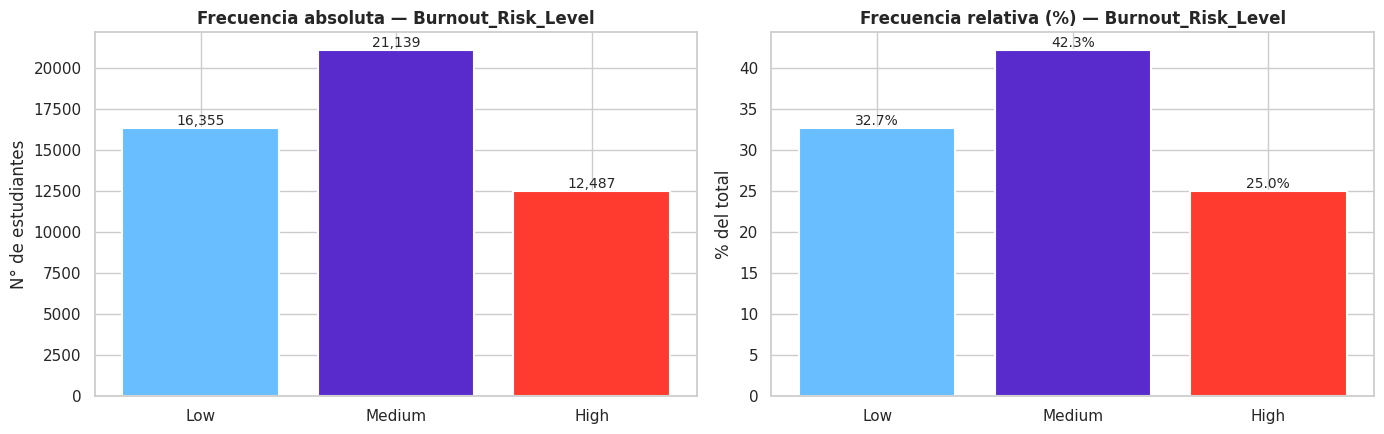

                        n      %
Burnout_Risk_Level              
Low                 16355  32.72
Medium              21139  42.29
High                12487  24.98

Ratio mayoritaria/minoritaria: 1.69x


In [85]:
target_counts = df[TARGET].value_counts().reindex(TARGET_ORDER)
target_pct    = df[TARGET].value_counts(normalize=True).reindex(TARGET_ORDER) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Frecuencia absoluta
bars1 = axes[0].bar(target_counts.index, target_counts.values,
                    color=[PALETTE_TARGET[k] for k in target_counts.index],
                    edgecolor='white', linewidth=1.5)
axes[0].set_title('Frecuencia absoluta — Burnout_Risk_Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('N° de estudiantes')
for b, v in zip(bars1, target_counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Frecuencia relativa
bars2 = axes[1].bar(target_pct.index, target_pct.values,
                    color=[PALETTE_TARGET[k] for k in target_pct.index],
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('Frecuencia relativa (%) — Burnout_Risk_Level', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% del total')
for b, v in zip(bars2, target_pct.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

resumen_target = pd.DataFrame({'n': target_counts, '%': target_pct.round(2)})
print(resumen_target.to_string())
print(f"\nRatio mayoritaria/minoritaria: {target_counts.max() / target_counts.min():.2f}x")

#### **4.3.2. Variables numéricas**

Se reutiliza la función `analyze_numeric_variable` (definida en 3.4) para mantener consistencia visual con la fase de detección de outliers. Se analizan primero las **continuas** y luego las **ordinales** (Likert 1-5 y 1-10), cuya distribución se interpreta de forma distinta.

>>> NUMÉRICAS CONTINUAS

--- Análisis de la variable 'Pre_Semester_GPA' ---


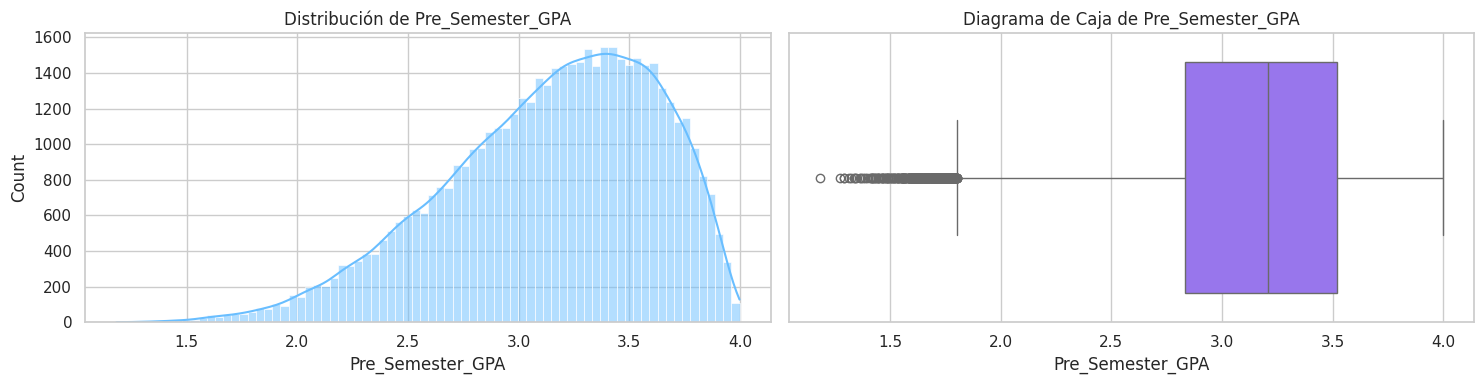


Reporte Estadístico para 'Pre_Semester_GPA':
• Outliers IQR: 327
  Límites: [1.80, 4.55]
• Outliers Z-Score (|z|>3): 196
--------------------------------------------------------------------------------

--- Análisis de la variable 'Post_Semester_GPA' ---


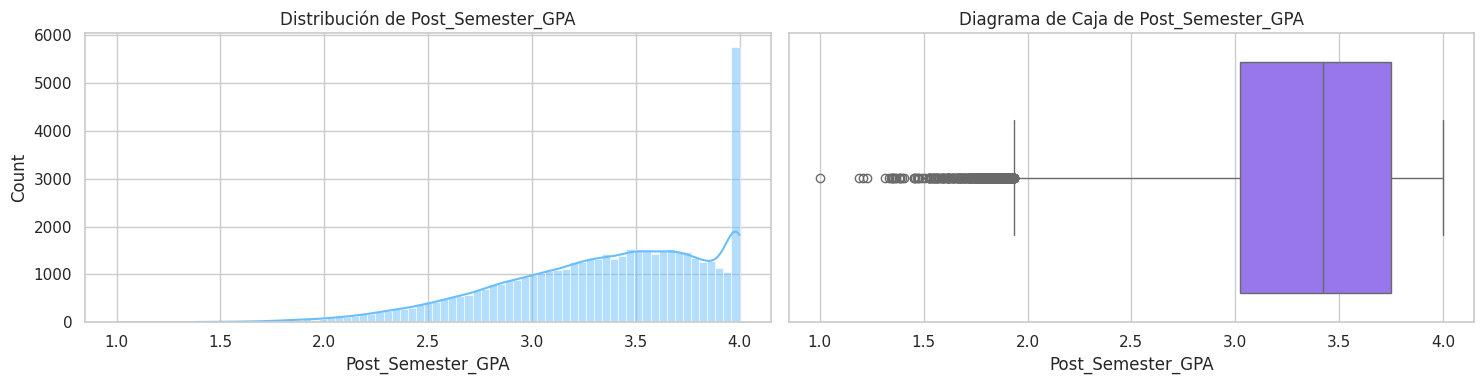


Reporte Estadístico para 'Post_Semester_GPA':
• Outliers IQR: 341
  Límites: [1.93, 4.84]
• Outliers Z-Score (|z|>3): 237
--------------------------------------------------------------------------------

--- Análisis de la variable 'Weekly_GenAI_Hours' ---


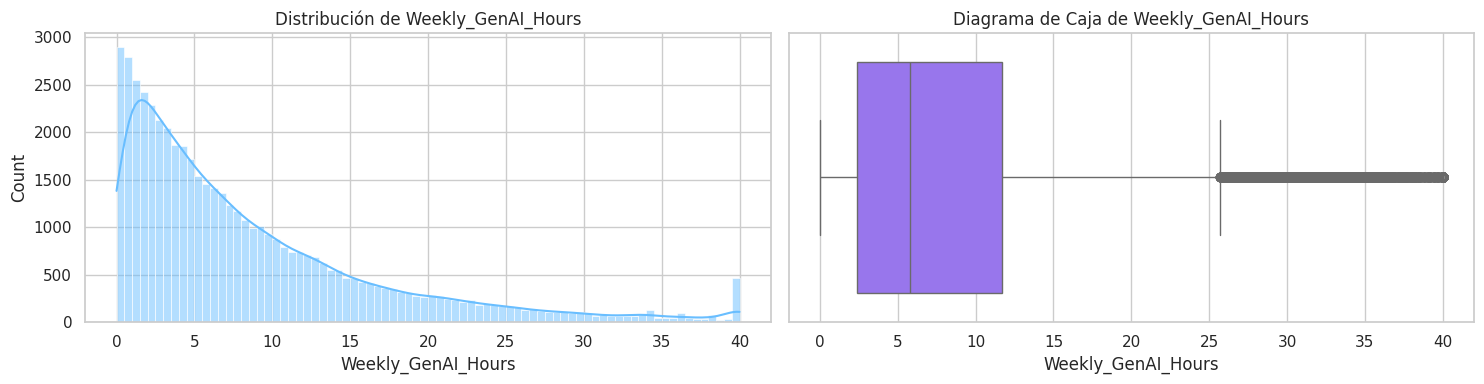


Reporte Estadístico para 'Weekly_GenAI_Hours':
• Outliers IQR: 2588
  Límites: [-11.58, 25.70]
• Outliers Z-Score (|z|>3): 1144
--------------------------------------------------------------------------------

--- Análisis de la variable 'Traditional_Study_Hours' ---


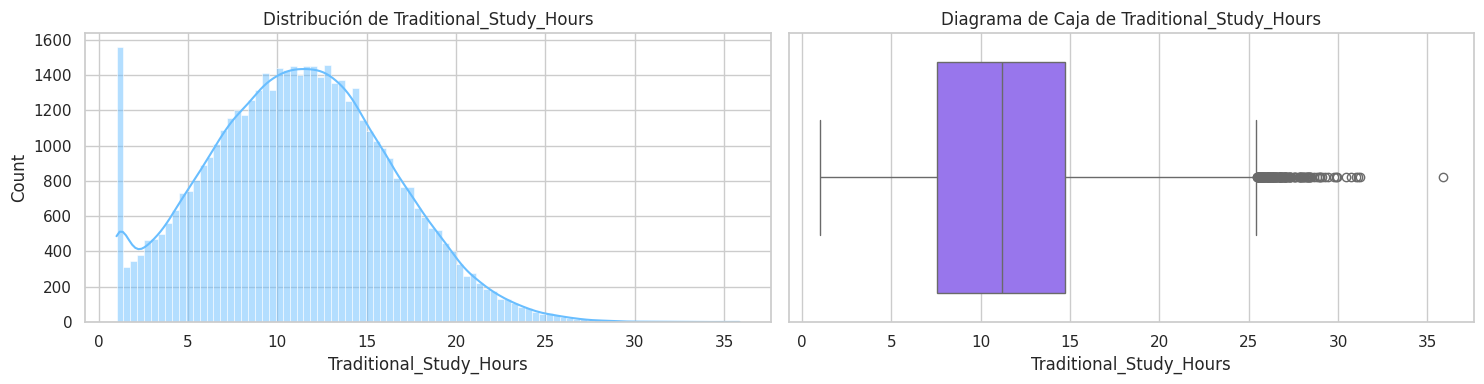


Reporte Estadístico para 'Traditional_Study_Hours':
• Outliers IQR: 161
  Límites: [-3.17, 25.44]
• Outliers Z-Score (|z|>3): 74
--------------------------------------------------------------------------------

--- Análisis de la variable 'Skill_Retention_Score' ---


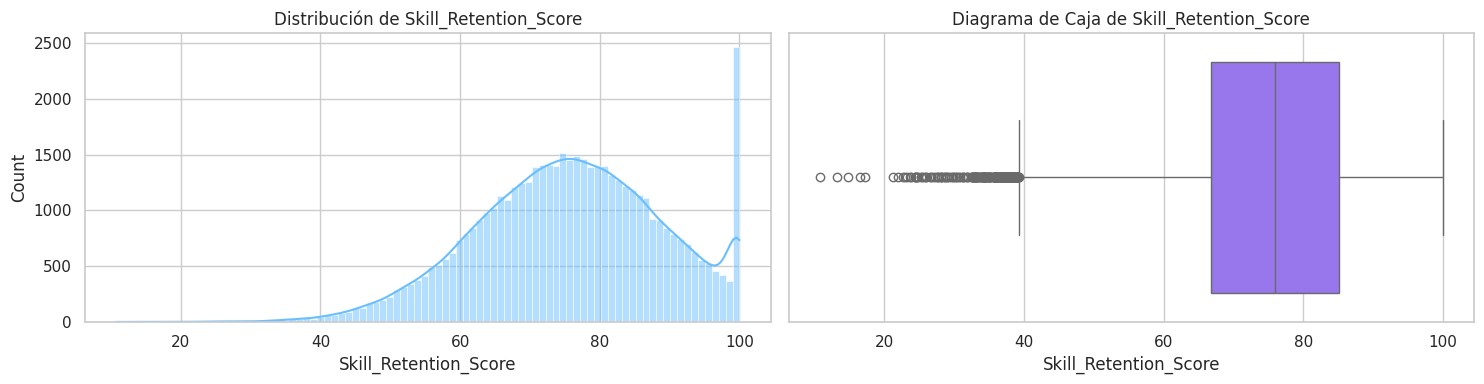


Reporte Estadístico para 'Skill_Retention_Score':
• Outliers IQR: 216
  Límites: [39.28, 112.72]
• Outliers Z-Score (|z|>3): 115
--------------------------------------------------------------------------------

--- Análisis de la variable 'Tool_Diversity' ---


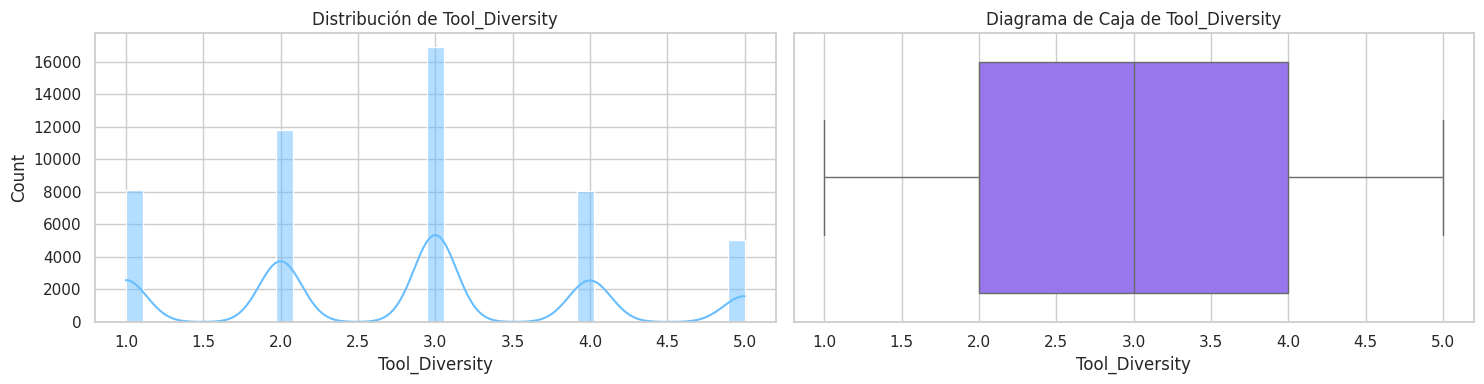


Reporte Estadístico para 'Tool_Diversity':
• Outliers IQR: 0
  Límites: [-1.00, 7.00]
• Outliers Z-Score (|z|>3): 0
--------------------------------------------------------------------------------


In [86]:
print(">>> NUMÉRICAS CONTINUAS")
for col in NUM_CONTINUAS:
    analyze_numeric_variable(df, col)

>>> NUMÉRICAS ORDINALES (escalas Likert)

--- Análisis de la variable 'Perceived_AI_Dependency' ---


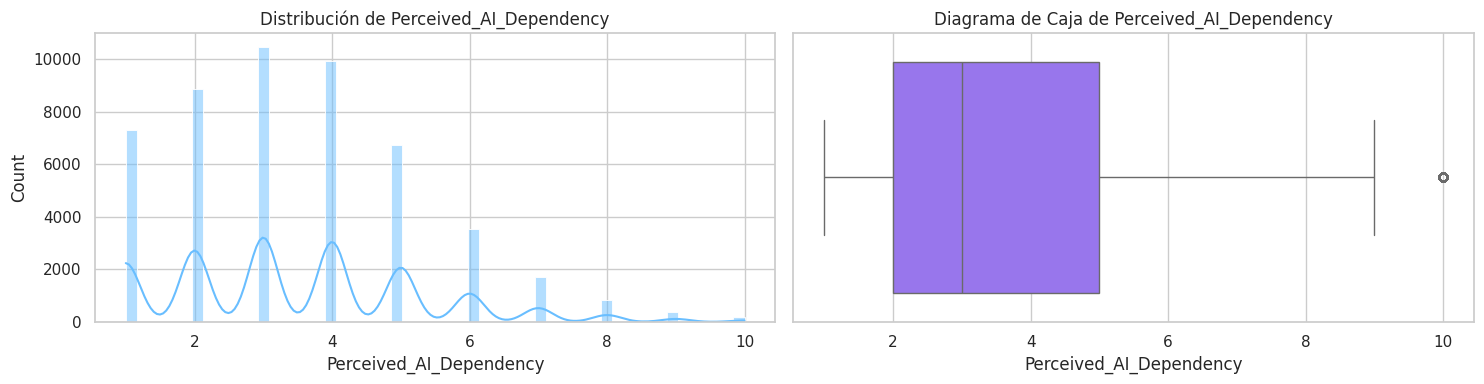


Reporte Estadístico para 'Perceived_AI_Dependency':
• Outliers IQR: 190
  Límites: [-2.50, 9.50]
• Outliers Z-Score (|z|>3): 568
--------------------------------------------------------------------------------

--- Análisis de la variable 'Anxiety_Level_During_Exams' ---


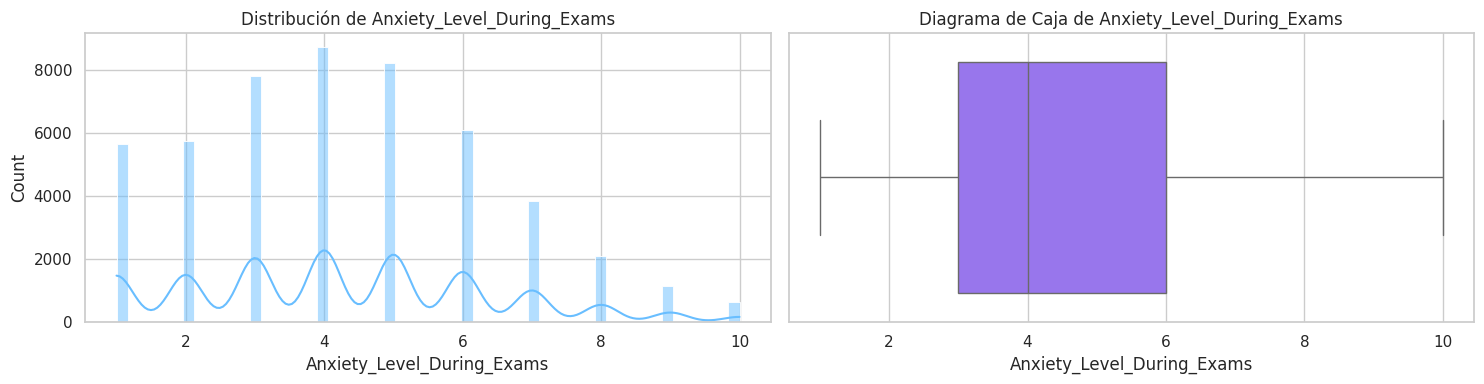


Reporte Estadístico para 'Anxiety_Level_During_Exams':
• Outliers IQR: 0
  Límites: [-1.50, 10.50]
• Outliers Z-Score (|z|>3): 0
--------------------------------------------------------------------------------


In [87]:
print(">>> NUMÉRICAS ORDINALES (escalas Likert)")
for col in NUM_ORDINALES:
    analyze_numeric_variable(df, col)

#### **4.3.3. Variables categóricas**

Distribución de cada variable categórica ordenada por frecuencia. Las etiquetas sobre las barras muestran el porcentaje de cada categoría dentro de la variable.

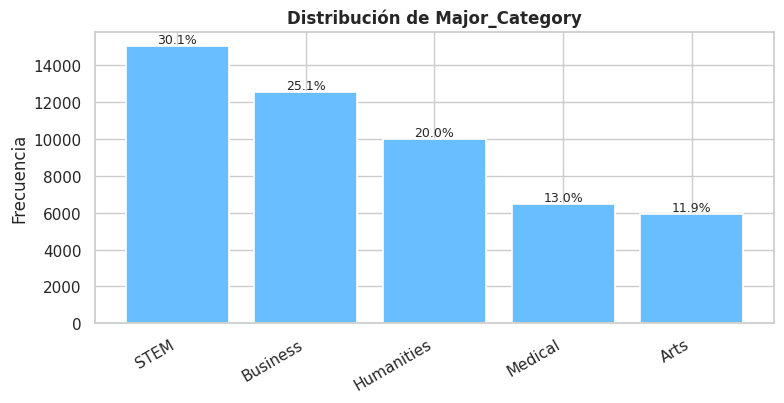

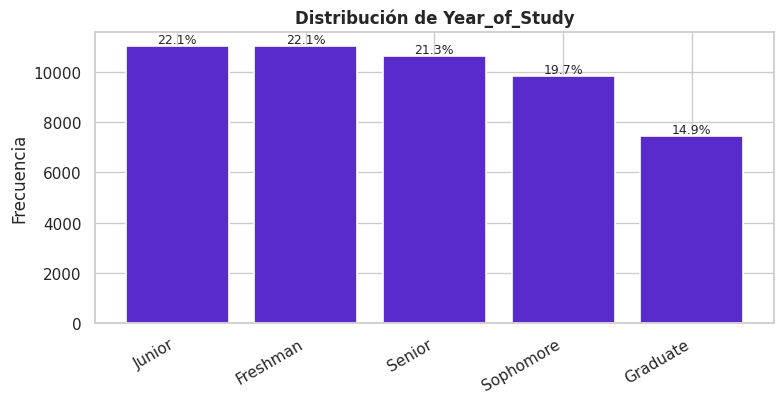

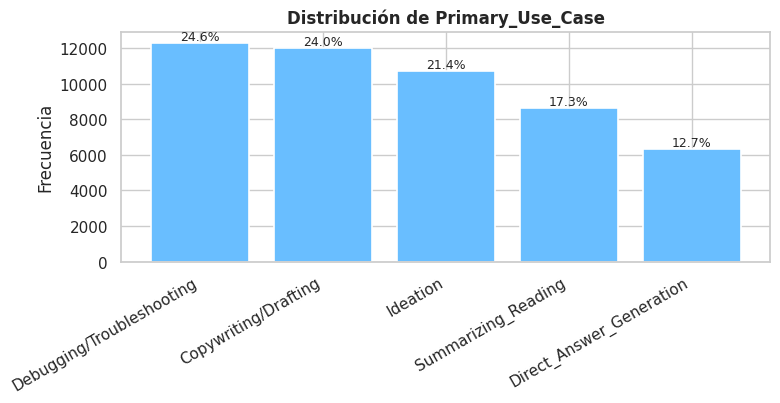

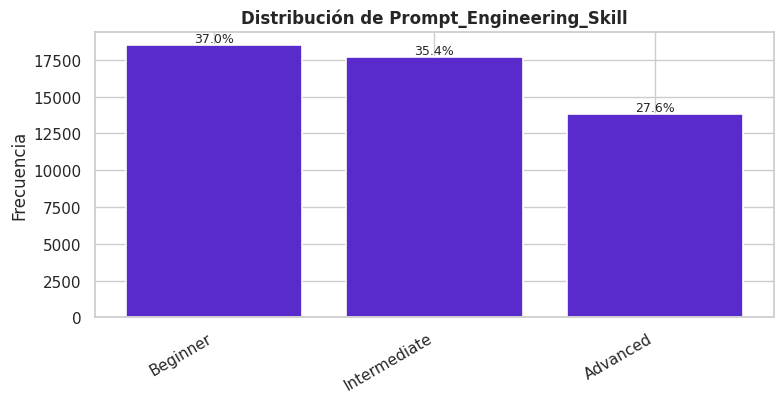

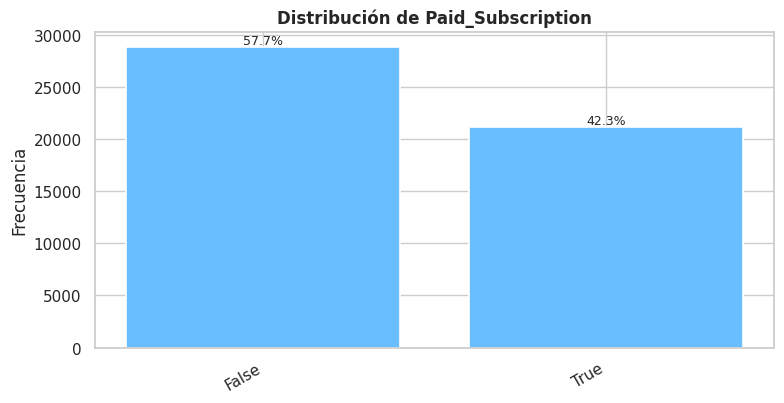

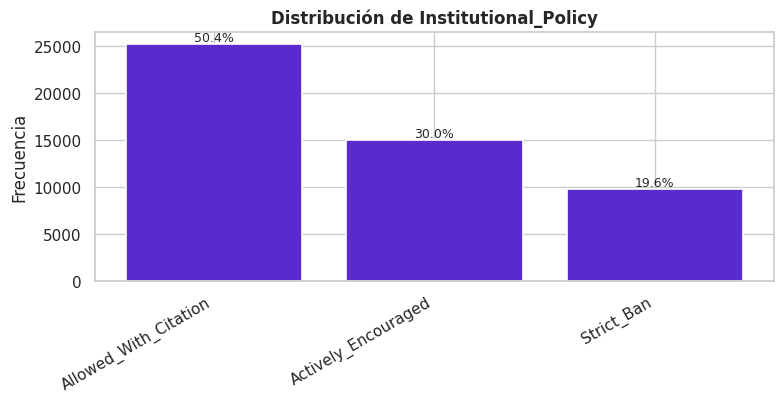

In [89]:
def plot_categorical(dataframe, column_name, color=COLOR_BLUE):
    counts = dataframe[column_name].value_counts()
    pct    = dataframe[column_name].value_counts(normalize=True) * 100

    fig, ax = plt.subplots(figsize=(max(8, len(counts) * 0.9), 4.2))
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Distribución de {column_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for b, v, p in zip(bars, counts.values, pct.values):
        ax.text(b.get_x() + b.get_width()/2, v, f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Alternar paleta azul/morado para diferenciar visualmente
for i, col in enumerate(CATEGORICAS):
    plot_categorical(df, col, color=COLOR_BLUE if i % 2 == 0 else COLOR_DARK)

### **4.4. Análisis bivariado vs. `Burnout_Risk_Level`**

#### **4.4.1. Numéricas vs. target**

Para cada variable numérica se comparan las distribuciones condicionadas por nivel de burnout mediante boxplot + violinplot. Diferencias marcadas en mediana, dispersión o forma señalan candidatos a predictor relevante.

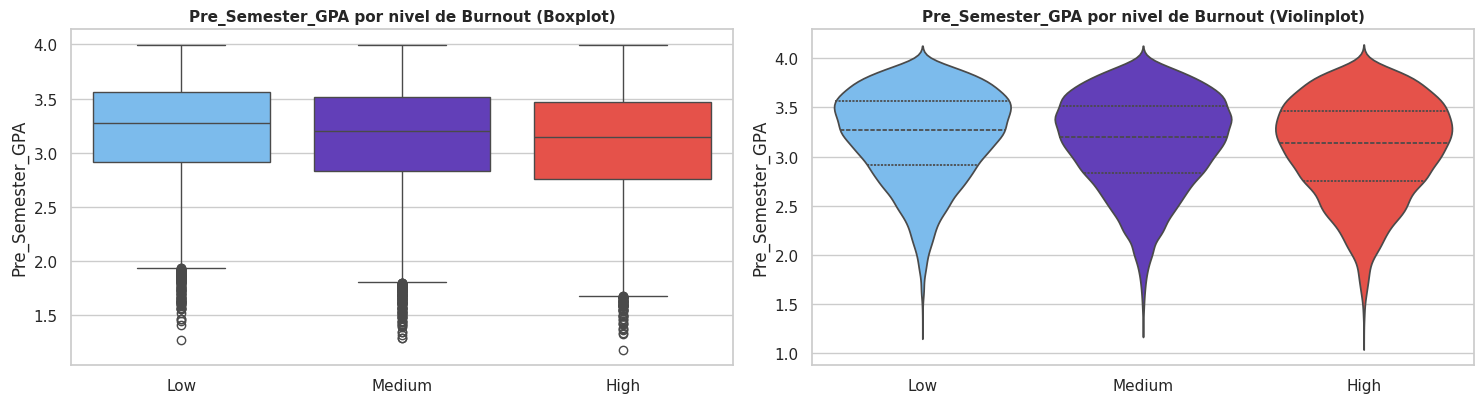

                     mean  median    std
Burnout_Risk_Level                      
Low                 3.204   3.271  0.460
Medium              3.139   3.200  0.479
High                3.083   3.143  0.495



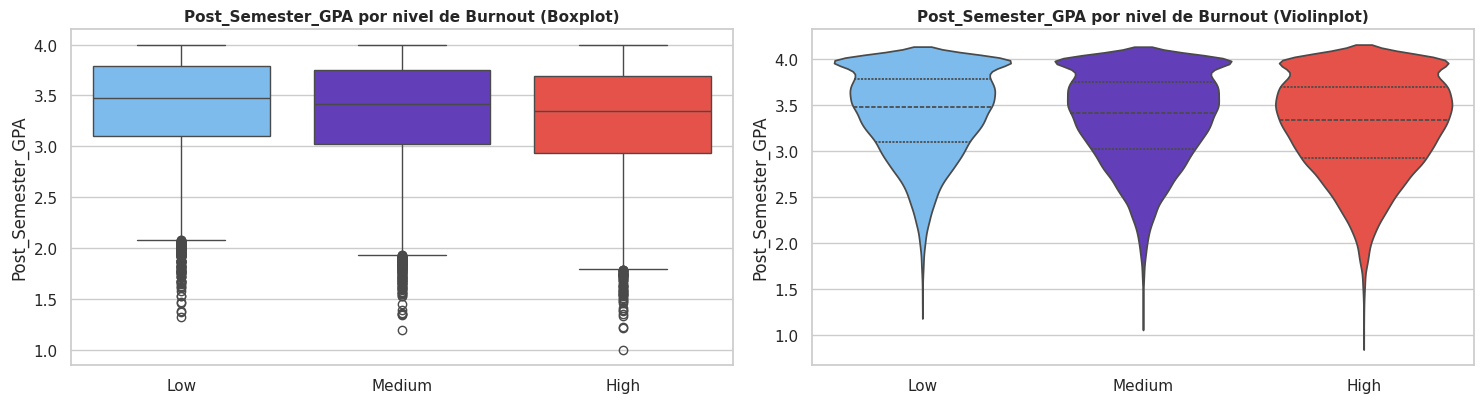

                     mean  median    std
Burnout_Risk_Level                      
Low                 3.405   3.479  0.472
Medium              3.348   3.419  0.493
High                3.278   3.343  0.520



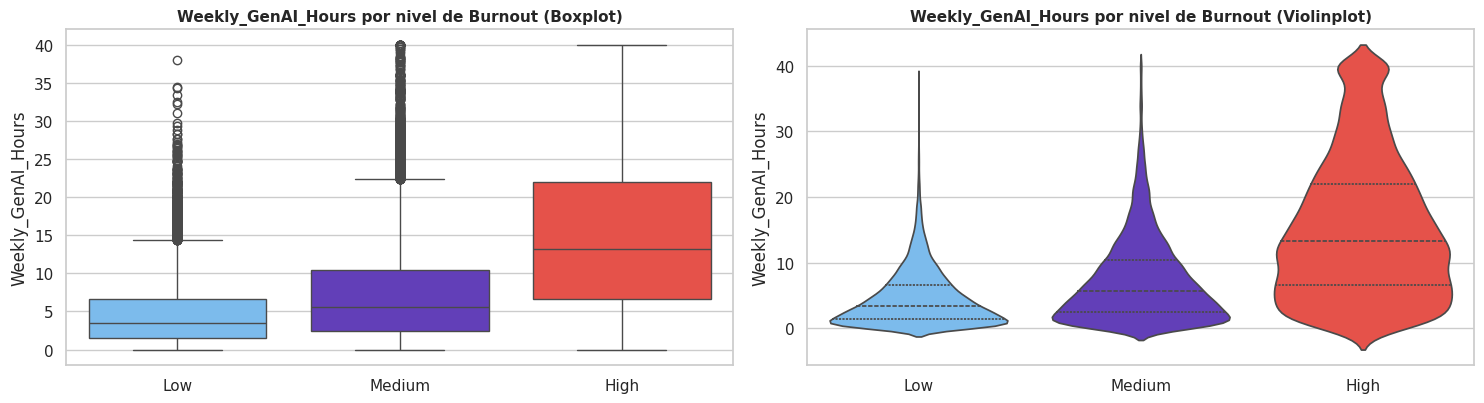

                      mean  median     std
Burnout_Risk_Level                        
Low                  4.648    3.42   4.265
Medium               7.351    5.63   6.453
High                15.215   13.25  10.614



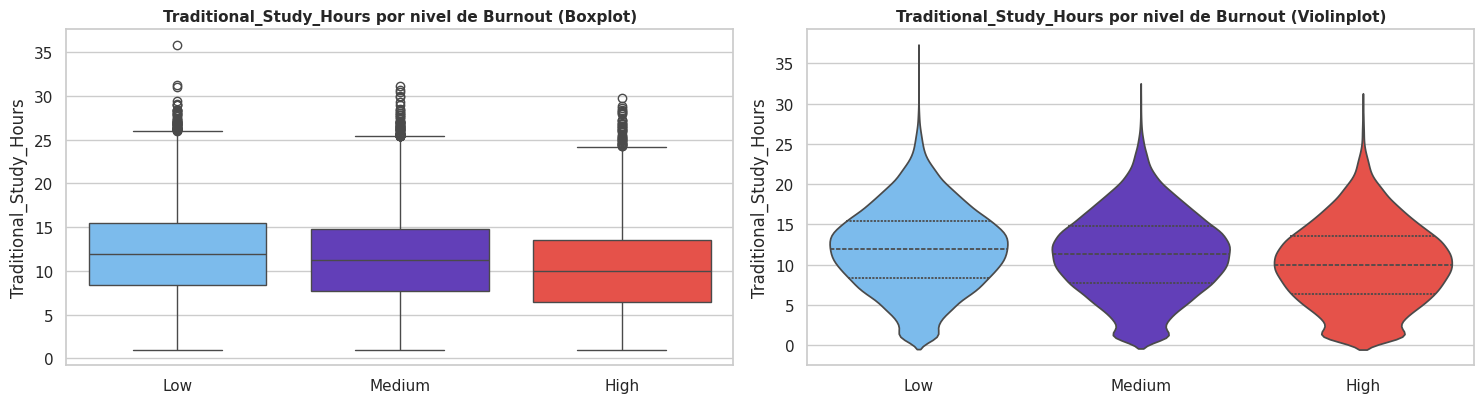

                      mean  median    std
Burnout_Risk_Level                       
Low                 11.966   11.97  5.136
Medium              11.290   11.28  5.113
High                10.082    9.99  5.059



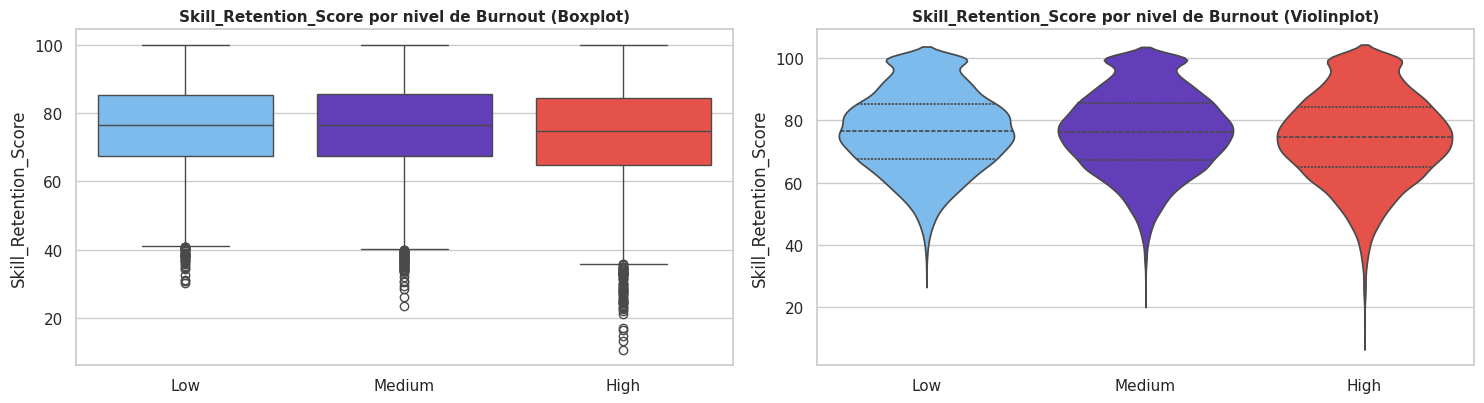

                      mean  median     std
Burnout_Risk_Level                        
Low                 76.400   76.44  12.834
Medium              76.244   76.42  12.986
High                74.253   74.60  14.203



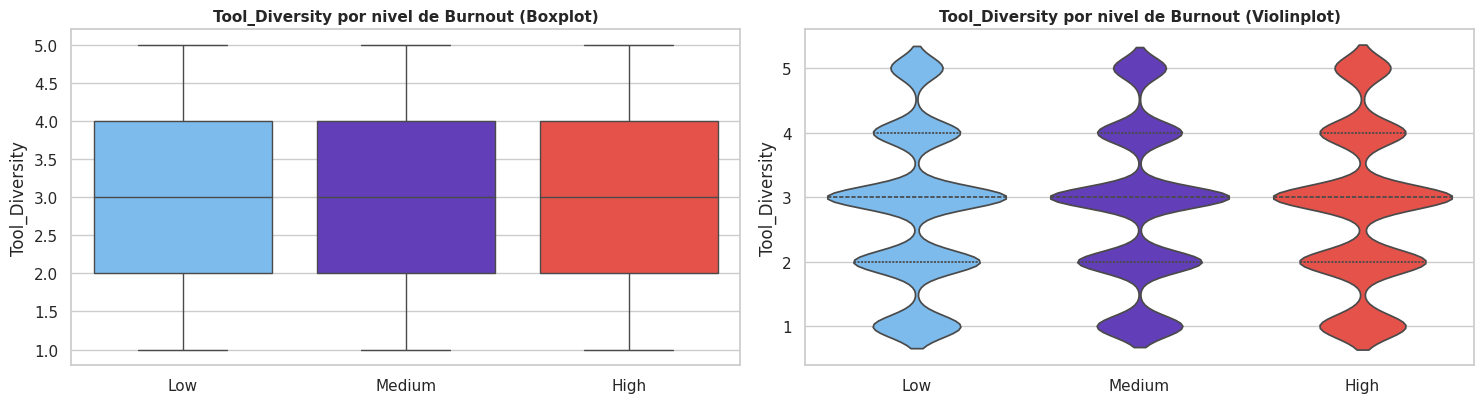

                     mean  median    std
Burnout_Risk_Level                      
Low                 2.793     3.0  1.186
Medium              2.800     3.0  1.186
High                2.811     3.0  1.194



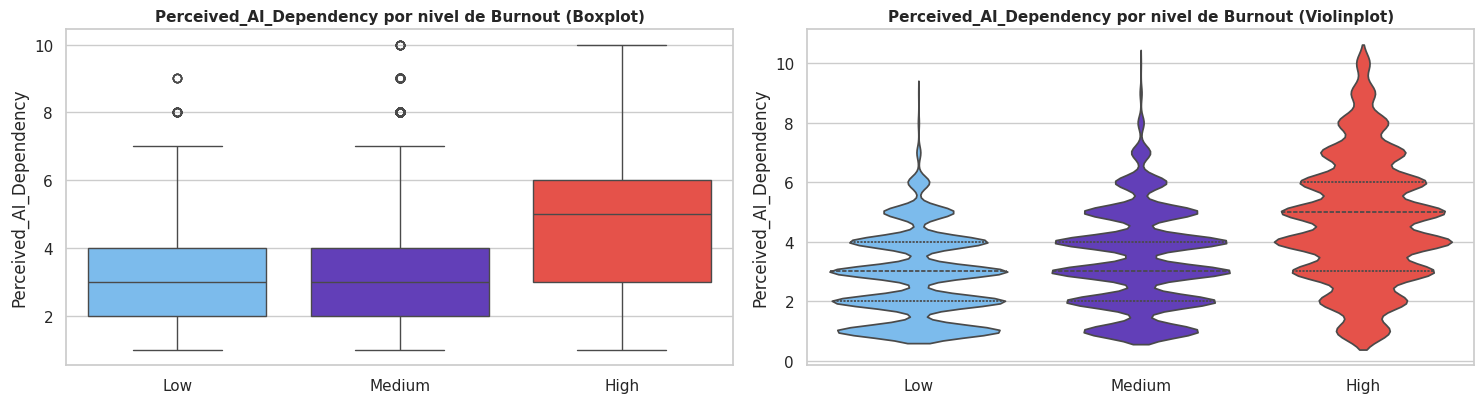

                     mean  median    std
Burnout_Risk_Level                      
Low                 2.820     3.0  1.421
Medium              3.365     3.0  1.621
High                4.642     5.0  2.059



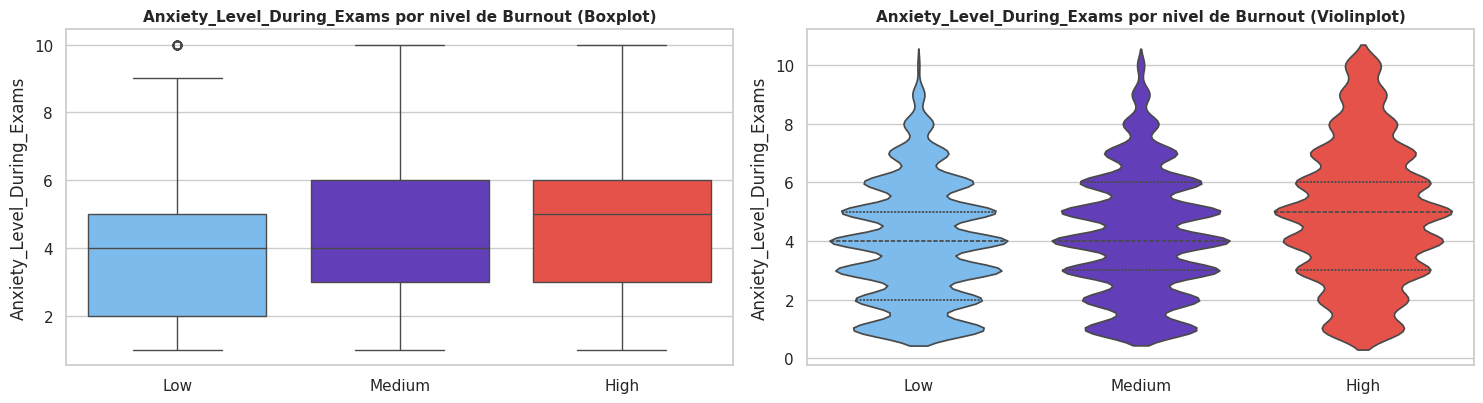

                     mean  median    std
Burnout_Risk_Level                      
Low                 3.928     4.0  1.987
Medium              4.171     4.0  2.067
High                4.889     5.0  2.333



In [90]:
def plot_numeric_by_target(dataframe, column_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

    # Boxplot con hue asignado para evitar FutureWarning
    sns.boxplot(data=dataframe, x=TARGET, y=column_name, order=TARGET_ORDER,
                hue=TARGET, palette=PALETTE_TARGET, ax=axes[0], legend=False)
    axes[0].set_title(f'{column_name} por nivel de Burnout (Boxplot)', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('')

    # Violinplot con hue asignado para evitar FutureWarning
    sns.violinplot(data=dataframe, x=TARGET, y=column_name, order=TARGET_ORDER,
                   hue=TARGET, palette=PALETTE_TARGET, ax=axes[1], inner='quartile', legend=False)
    axes[1].set_title(f'{column_name} por nivel de Burnout (Violinplot)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()

    # Resumen estadístico por grupo
    resumen = dataframe.groupby(TARGET)[column_name].agg(['mean', 'median', 'std']).round(3)
    resumen = resumen.reindex(TARGET_ORDER)
    print(resumen.to_string())
    print()

for col in NUMERICAS:
    plot_numeric_by_target(df, col)

#### **4.4.2. Categóricas vs. target**

Barras apiladas normalizadas: cada barra representa una categoría y el color muestra la composición porcentual de niveles de burnout. Si una categoría tiene una composición claramente distinta del resto, sugiere asociación con el target.

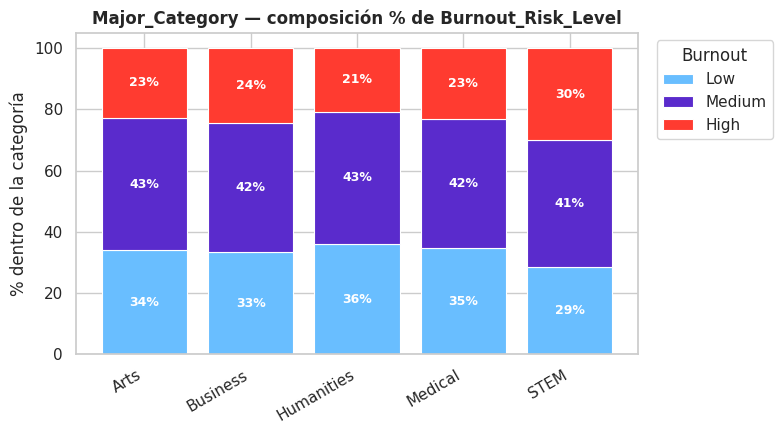

Burnout_Risk_Level    Low  Medium   High
Major_Category                          
Arts                33.93   43.37  22.69
Business            33.40   42.25  24.35
Humanities          36.07   43.18  20.75
Medical             34.64   42.20  23.16
STEM                28.64   41.36  30.00



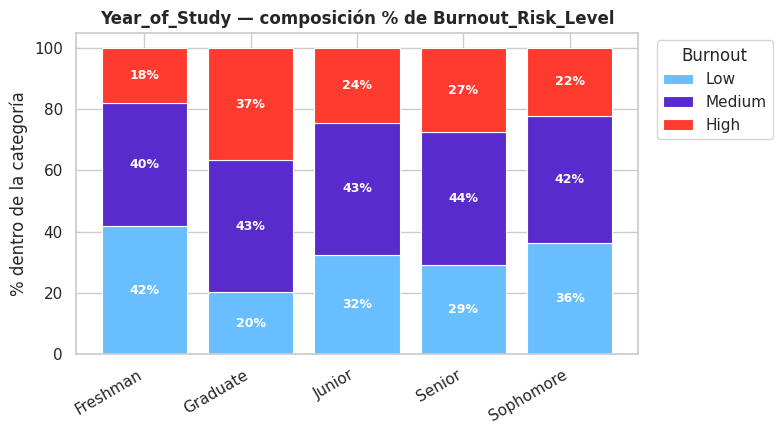

Burnout_Risk_Level    Low  Medium   High
Year_of_Study                           
Freshman            41.80   40.22  17.98
Graduate            20.20   43.07  36.73
Junior              32.46   43.19  24.35
Senior              28.98   43.59  27.42
Sophomore           36.33   41.62  22.05



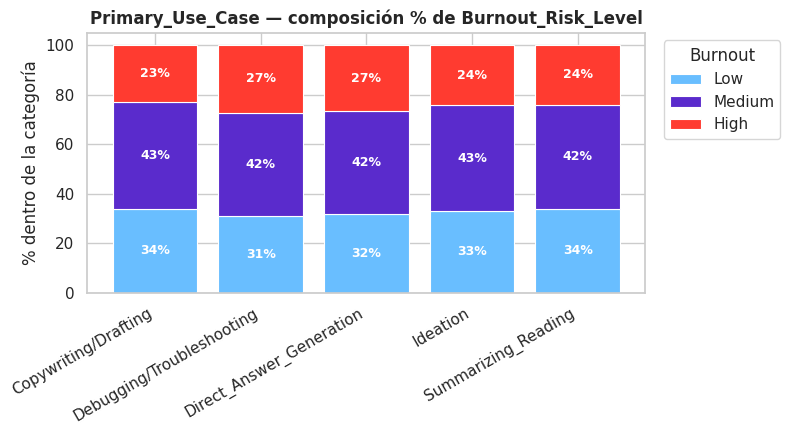

Burnout_Risk_Level           Low  Medium   High
Primary_Use_Case                               
Copywriting/Drafting       33.92   43.09  23.00
Debugging/Troubleshooting  31.08   41.63  27.29
Direct_Answer_Generation   31.88   41.50  26.61
Ideation                   32.99   42.64  24.37
Summarizing_Reading        33.69   42.28  24.03



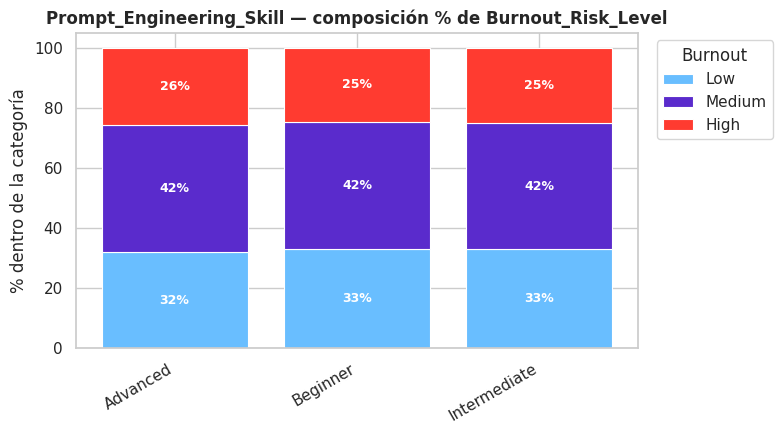

Burnout_Risk_Level          Low  Medium   High
Prompt_Engineering_Skill                      
Advanced                  32.03   42.45  25.52
Beginner                  33.05   42.30  24.65
Intermediate              32.92   42.17  24.91



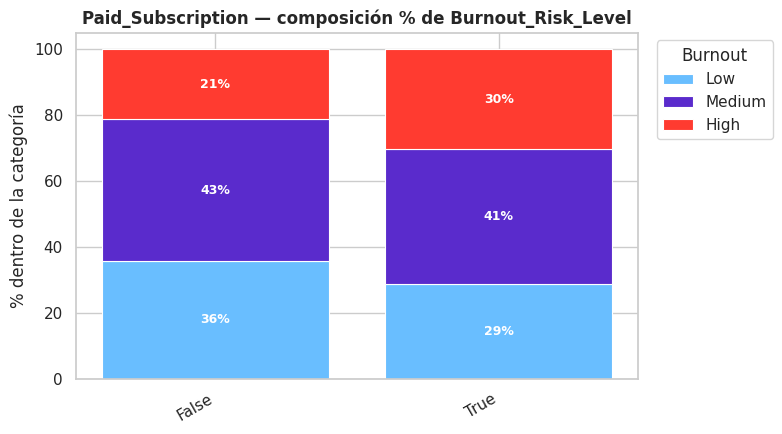

Burnout_Risk_Level    Low  Medium   High
Paid_Subscription                       
False               35.58   43.31  21.12
True                28.83   40.92  30.26



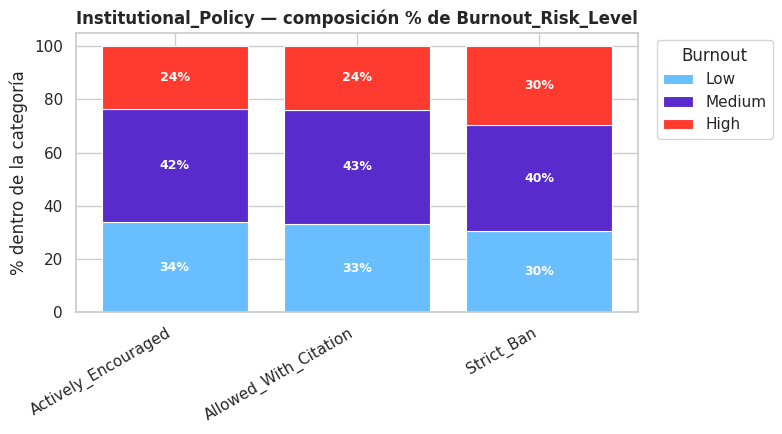

Burnout_Risk_Level       Low  Medium   High
Institutional_Policy                       
Actively_Encouraged    33.88   42.34  23.78
Allowed_With_Citation  32.96   43.20  23.84
Strict_Ban             30.34   39.90  29.76



In [91]:
def plot_categorical_by_target(dataframe, column_name):
    ct = pd.crosstab(dataframe[column_name], dataframe[TARGET], normalize='index') * 100
    ct = ct[TARGET_ORDER]

    fig, ax = plt.subplots(figsize=(max(8, len(ct) * 0.9), 4.5))
    bottom = np.zeros(len(ct))
    for nivel in TARGET_ORDER:
        ax.bar(ct.index.astype(str), ct[nivel], bottom=bottom,
               color=PALETTE_TARGET[nivel], label=nivel, edgecolor='white', linewidth=0.8)
        for i, (idx, v) in enumerate(ct[nivel].items()):
            if v >= 5:  # solo etiquetar segmentos visibles
                ax.text(i, bottom[i] + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += ct[nivel].values

    ax.set_title(f'{column_name} — composición % de Burnout_Risk_Level', fontsize=12, fontweight='bold')
    ax.set_ylabel('% dentro de la categoría')
    ax.legend(title='Burnout', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print(ct.round(2).to_string())
    print()

for col in CATEGORICAS:
    plot_categorical_by_target(df, col)

#### **4.4.3. Tests estadísticos de asociación**

Cuantificación formal de la asociación de cada predictor con `Burnout_Risk_Level`:

- **Numéricas vs. target (3 grupos):** Kruskal-Wallis (no paramétrico, robusto a no-normalidad). H0: las distribuciones son iguales entre los 3 grupos.
- **Categóricas vs. target:** Chi-cuadrado de independencia + **Cramér's V** como tamaño del efecto (0 = sin asociación, 1 = perfecta).

Se reportan ordenadas por evidencia de asociación.

In [92]:
# Kruskal-Wallis: numéricas vs target
resultados_kw = []
grupos_target = [df.loc[df[TARGET] == n, NUMERICAS] for n in TARGET_ORDER]
for col in NUMERICAS:
    stat, pval = stats.kruskal(*[g[col].dropna() for g in grupos_target])
    resultados_kw.append({'variable': col, 'H_stat': stat, 'p_value': pval,
                          'significativo (α=0.05)': pval < 0.05})

tabla_kw = pd.DataFrame(resultados_kw).sort_values('p_value').reset_index(drop=True)
tabla_kw['H_stat']  = tabla_kw['H_stat'].round(3)
tabla_kw['p_value'] = tabla_kw['p_value'].apply(lambda x: f'{x:.2e}')
print("KRUSKAL-WALLIS — numéricas vs. Burnout_Risk_Level")
print(tabla_kw.to_string(index=False))

KRUSKAL-WALLIS — numéricas vs. Burnout_Risk_Level
                  variable   H_stat   p_value  significativo (α=0.05)
        Weekly_GenAI_Hours 9962.484  0.00e+00                    True
   Perceived_AI_Dependency 6199.925  0.00e+00                    True
Anxiety_Level_During_Exams 1239.548 6.85e-270                    True
   Traditional_Study_Hours  932.203 3.76e-203                    True
          Pre_Semester_GPA  443.707  4.47e-97                    True
         Post_Semester_GPA  411.990  3.45e-90                    True
     Skill_Retention_Score  171.589  5.49e-38                    True
            Tool_Diversity    1.193  5.51e-01                   False


In [93]:
# Chi-cuadrado + Cramér's V: categóricas vs target
def cramers_v(contingency):
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

resultados_chi = []
for col in CATEGORICAS:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, pval, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    resultados_chi.append({'variable': col, 'chi2': chi2, 'dof': dof,
                           'p_value': pval, "Cramér_V": v,
                           'significativo (α=0.05)': pval < 0.05})

tabla_chi = pd.DataFrame(resultados_chi).sort_values("Cramér_V", ascending=False).reset_index(drop=True)
tabla_chi['chi2']      = tabla_chi['chi2'].round(3)
tabla_chi["Cramér_V"]  = tabla_chi["Cramér_V"].round(4)
tabla_chi['p_value']   = tabla_chi['p_value'].apply(lambda x: f'{x:.2e}')
print("CHI-CUADRADO + CRAMÉR'S V — categóricas vs. Burnout_Risk_Level")
print(tabla_chi.to_string(index=False))

CHI-CUADRADO + CRAMÉR'S V — categóricas vs. Burnout_Risk_Level
                variable     chi2  dof   p_value  Cramér_V  significativo (α=0.05)
           Year_of_Study 1426.080    8 1.30e-302    0.1194                    True
       Paid_Subscription  594.234    2 9.20e-130    0.1090                    True
          Major_Category  375.835    8  2.75e-76    0.0613                    True
    Institutional_Policy  152.928    4  4.80e-32    0.0391                    True
        Primary_Use_Case   80.323    8  4.21e-14    0.0283                    True
Prompt_Engineering_Skill    5.420    4  2.47e-01    0.0074                   False


### **4.5. Análisis multivariado**

#### **4.5.1. Correlaciones entre variables numéricas**

Heatmap de correlación de **Spearman** (rangos) — más apropiado que Pearson dado que incluimos variables ordinales (Anxiety, Dependency) y no podemos asumir linealidad estricta. Valores cercanos a ±1 indican relaciones monótonas fuertes.

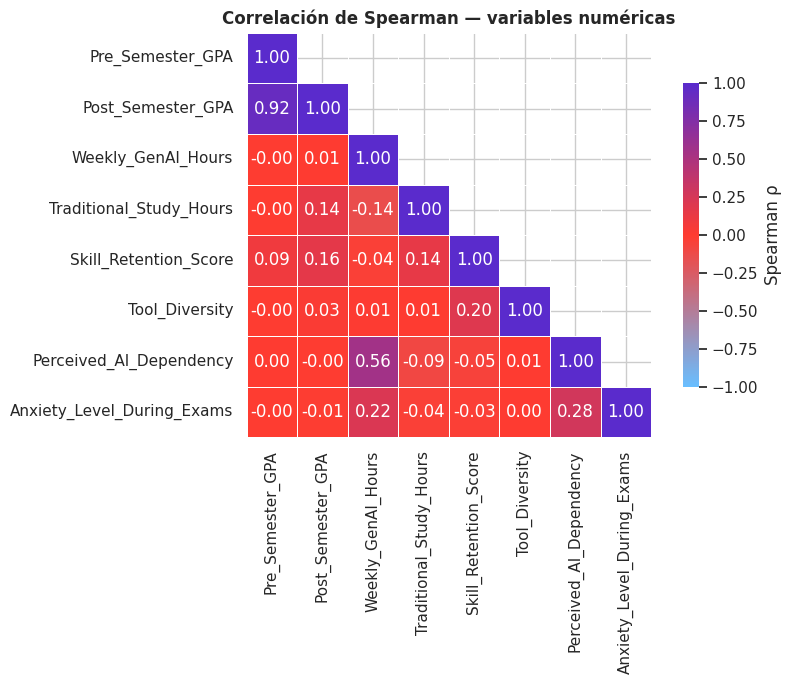

Top 10 pares por |ρ|:
                     var_1                   var_2    rho
         Post_Semester_GPA        Pre_Semester_GPA  0.917
   Perceived_AI_Dependency      Weekly_GenAI_Hours  0.555
Anxiety_Level_During_Exams Perceived_AI_Dependency  0.280
Anxiety_Level_During_Exams      Weekly_GenAI_Hours  0.221
     Skill_Retention_Score          Tool_Diversity  0.202
         Post_Semester_GPA   Skill_Retention_Score  0.160
     Skill_Retention_Score Traditional_Study_Hours  0.142
         Post_Semester_GPA Traditional_Study_Hours  0.141
   Traditional_Study_Hours      Weekly_GenAI_Hours -0.136
          Pre_Semester_GPA   Skill_Retention_Score  0.093


In [94]:
corr = df[NUMERICAS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=CMAP_BP,
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Spearman ρ'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Correlación de Spearman — variables numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Top pares por |correlación|, excluyendo diagonal
pares = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack()
             .reset_index()
             .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'rho'}))
pares['abs_rho'] = pares['rho'].abs()
pares = (pares[pares['var_1'] < pares['var_2']]
         .sort_values('abs_rho', ascending=False)
         .head(10)
         .drop(columns='abs_rho')
         .reset_index(drop=True))
print("Top 10 pares por |ρ|:")
print(pares.round(3).to_string(index=False))

#### **4.5.2. Relaciones clave coloreadas por target**

Scatterplots de las relaciones más informativas según los tests previos. El color codifica el nivel de burnout para detectar segmentación visual.

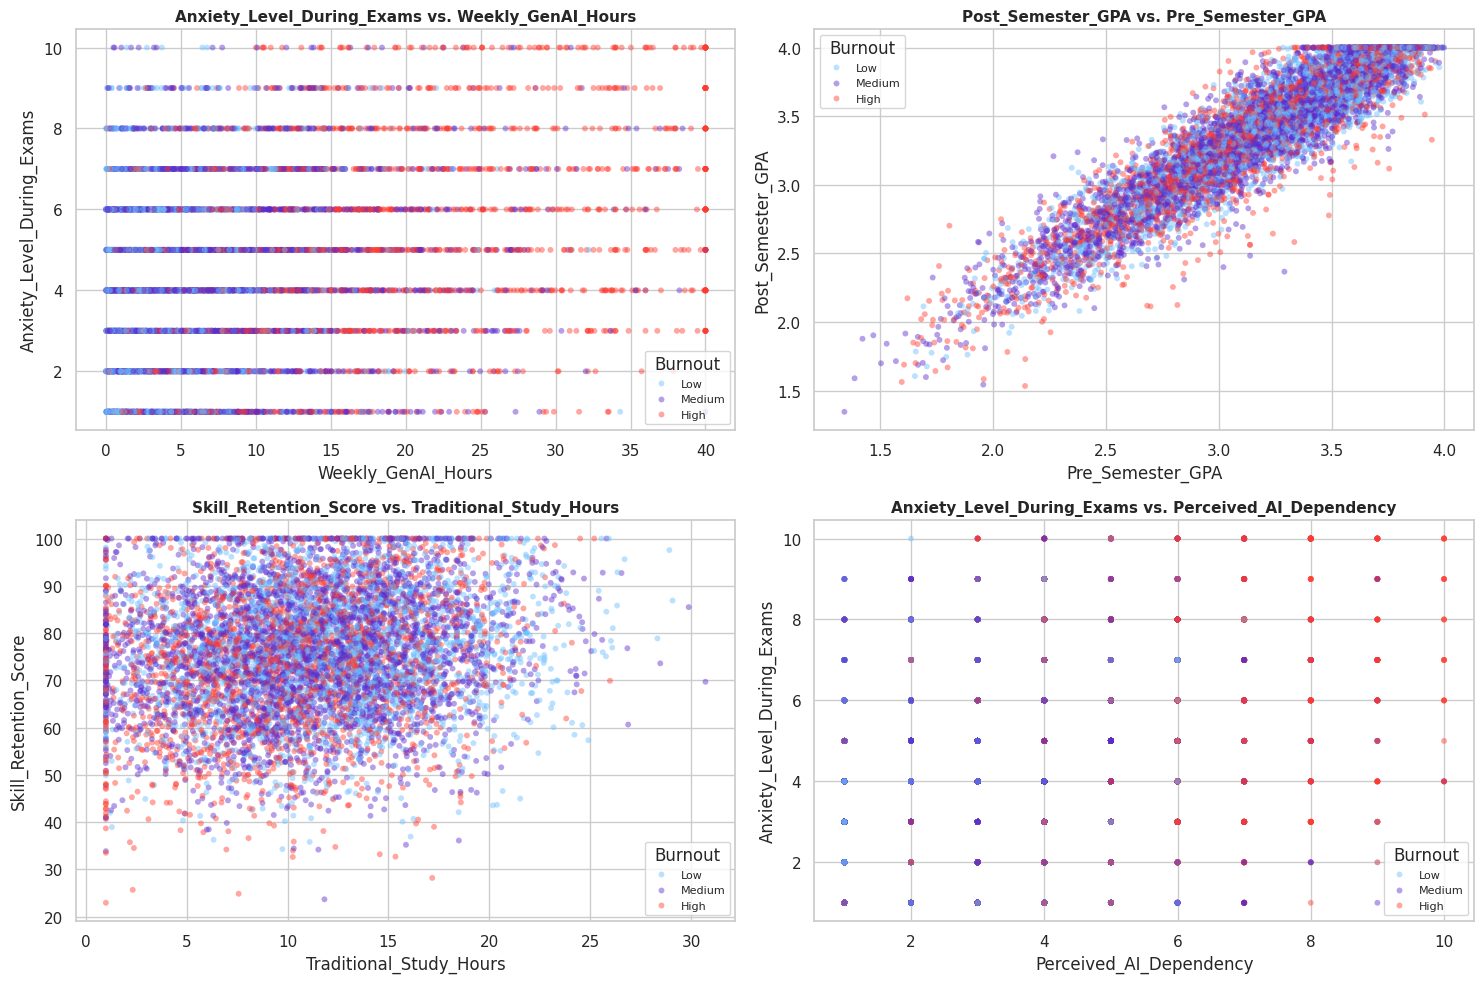

In [95]:
pares_clave = [
    ('Weekly_GenAI_Hours',        'Anxiety_Level_During_Exams'),
    ('Pre_Semester_GPA',          'Post_Semester_GPA'),
    ('Traditional_Study_Hours',   'Skill_Retention_Score'),
    ('Perceived_AI_Dependency',   'Anxiety_Level_During_Exams'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (x, y) in zip(axes.flat, pares_clave):
    sns.scatterplot(data=df.sample(min(8000, len(df)), random_state=42),
                    x=x, y=y, hue=TARGET, hue_order=TARGET_ORDER,
                    palette=PALETTE_TARGET, alpha=0.45, s=18,
                    edgecolor='none', ax=ax)
    ax.set_title(f'{y} vs. {x}', fontsize=11, fontweight='bold')
    ax.legend(title='Burnout', loc='best', fontsize=8)

plt.tight_layout()
plt.show()

#### **4.5.3. Variación académica intra-semestre (`Post − Pre GPA`)**

Variable derivada **solo para EDA** (no se persiste en el dataset). Mide el cambio de desempeño durante el semestre. Una caída sistemática en estudiantes con burnout alto sería evidencia conductual del impacto del riesgo.

/tmp/ipykernel_2019/261513226.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_eda, x=TARGET, y='Delta_GPA', order=TARGET_ORDER,


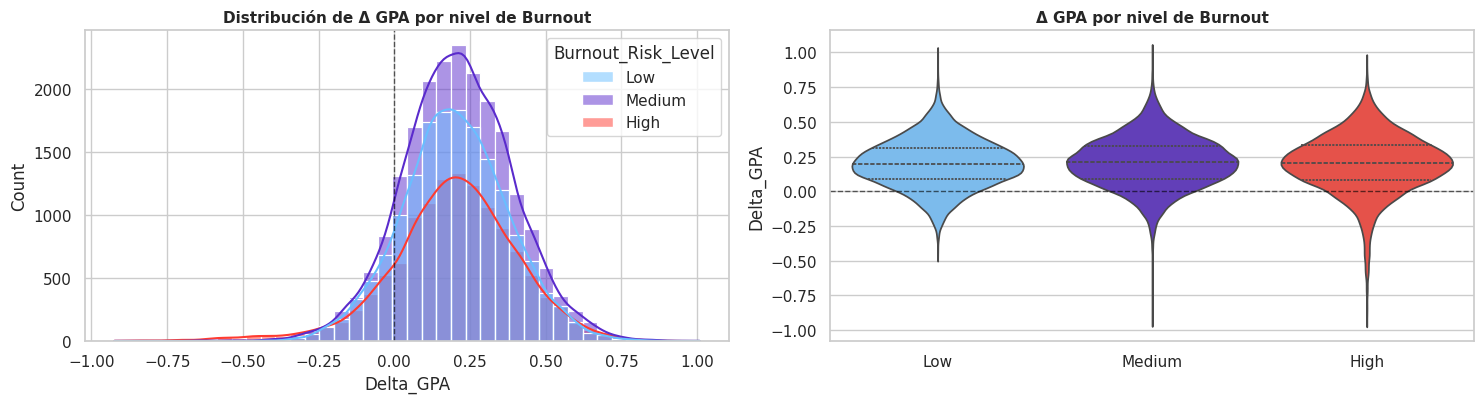

                      mean  median     std
Burnout_Risk_Level                        
Low                 0.2003   0.198  0.1750
Medium              0.2098   0.208  0.1812
High                0.1956   0.204  0.2107

Kruskal-Wallis sobre Δ GPA: H = 28.078, p = 8.00e-07


In [97]:
df_eda = df.copy()
df_eda['Delta_GPA'] = df_eda['Post_Semester_GPA'] - df_eda['Pre_Semester_GPA']

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

sns.histplot(data=df_eda, x='Delta_GPA', hue=TARGET, hue_order=TARGET_ORDER,
             palette=PALETTE_TARGET, kde=True, alpha=0.5, ax=axes[0], bins=40)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Distribución de Δ GPA por nivel de Burnout', fontsize=11, fontweight='bold')

sns.violinplot(data=df_eda, x=TARGET, y='Delta_GPA', order=TARGET_ORDER,
               palette=PALETTE_TARGET, ax=axes[1], inner='quartile')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Δ GPA por nivel de Burnout', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

resumen_delta = df_eda.groupby(TARGET)['Delta_GPA'].agg(['mean', 'median', 'std']).round(4)
resumen_delta = resumen_delta.reindex(TARGET_ORDER)
print(resumen_delta.to_string())

# Test formal del Δ
stat, pval = stats.kruskal(*[df_eda.loc[df_eda[TARGET] == n, 'Delta_GPA'] for n in TARGET_ORDER])
print(f"\nKruskal-Wallis sobre Δ GPA: H = {stat:.3f}, p = {pval:.2e}")

### **4.6. Análisis de desbalance de clases**

Cuantificación formal del desbalance del target. Este resultado condiciona directamente decisiones de la sección 5 (Preprocesamiento): estratificación del split, uso de `class_weight` en modelos sensibles, y evaluación con métricas robustas al desbalance (macro-F1, balanced accuracy, matriz de confusión normalizada).

In [98]:
counts = df[TARGET].value_counts().reindex(TARGET_ORDER)
pct    = (counts / counts.sum() * 100).round(2)

mayor, menor = counts.max(), counts.min()
ratio = mayor / menor
# Entropía normalizada como índice de balance (1 = perfecto balance, 0 = totalmente desbalanceado)
p = counts / counts.sum()
entropia_norm = (-(p * np.log(p)).sum()) / np.log(len(counts))

tabla = pd.DataFrame({'n': counts, '%': pct})
tabla.loc['TOTAL'] = [counts.sum(), 100.0]
print("DESBALANCE DEL TARGET")
print(tabla.to_string())
print(f"\nClase mayoritaria: {counts.idxmax()} ({mayor:,} | {pct.max():.2f}%)")
print(f"Clase minoritaria: {counts.idxmin()} ({menor:,} | {pct.min():.2f}%)")
print(f"Ratio mayor/menor: {ratio:.2f}x")
print(f"Entropía normalizada (1=balance perfecto): {entropia_norm:.4f}")

# Implicancias
print("\nIMPLICANCIAS PARA MODELADO:")
if ratio < 1.5:
    print("  • Desbalance leve. Métricas estándar son adecuadas.")
elif ratio < 3:
    print("  • Desbalance moderado. Usar split estratificado y reportar macro-F1.")
else:
    print("  • Desbalance fuerte. Usar split estratificado, class_weight='balanced',")
    print("    y evaluar undersampling de la clase mayoritaria (no se usará oversampling")
    print("    sintético como SMOTE por riesgo de introducir patrones artificiales).")

DESBALANCE DEL TARGET
                          n       %
Burnout_Risk_Level                 
Low                 16355.0   32.72
Medium              21139.0   42.29
High                12487.0   24.98
TOTAL               49981.0  100.00

Clase mayoritaria: Medium (21,139 | 42.29%)
Clase minoritaria: High (12,487 | 24.98%)
Ratio mayor/menor: 1.69x
Entropía normalizada (1=balance perfecto): 0.9794

IMPLICANCIAS PARA MODELADO:
  • Desbalance moderado. Usar split estratificado y reportar macro-F1.


### **4.7. Hallazgos consolidados del EDA**

Síntesis priorizada de la evidencia recolectada en 4.1–4.6. Estos hallazgos son los inputs directos a las decisiones de la Sección 5 (Preprocesamiento) y al diseño experimental de la Sección 6 (Modelamiento).

#### **A. Predictores con asociación fuerte al target**

Variables que muestran tanto significancia estadística (p < 0.05) como un tamaño de efecto relevante:

1.  **Weekly_GenAI_Hours (H=9962.5):** Es el predictor numérico más fuerte. Los grupos de riesgo alto muestran un uso significativamente mayor de IA.
2.  **Perceived_AI_Dependency (H=6199.9):** Existe una relación directa entre sentir dependencia y el nivel de burnout.
3.  **Year_of_Study (Cramér's V = 0.1194):** Es la variable categórica más influyente, con los estudiantes de postgrado (Graduate) mostrando una mayor proporción de riesgo alto (36.7%).
4.  **Anxiety_Level_During_Exams (H=1239.5):** Correlación clara: a mayor ansiedad, mayor nivel de riesgo.

#### **B. Predictores con asociación débil o nula**

Candidatas a exclusión o menor peso:

*   **Tool_Diversity (p=0.55):** No se halló evidencia de que la cantidad de herramientas usadas varíe entre niveles de burnout.
*   **Prompt_Engineering_Skill (p=0.247):** La habilidad técnica en IA no parece influir en el riesgo de agotamiento.

#### **C. Riesgo de redundancia / multicolinealidad**

*   **Pre vs. Post GPA (ρ = 0.917):** Existe una correlación extremadamente alta. Mantener ambas podría introducir ruido o inestabilidad en modelos lineales. Se sugiere priorizar `Pre_Semester_GPA` o usar el `Delta_GPA`.
*   **Weekly_GenAI_Hours vs Dependency (ρ = 0.555):** Asociación moderada-alta, esperada por la naturaleza de las variables.

#### **D. Riesgo de data leakage**

`Post_Semester_GPA` tiene una correlación de **0.927** con el GPA previo y se mide simultáneamente con el burnout. Dado que el burnout afecta el rendimiento, esta variable actúa más como una consecuencia que como un predictor temprano. **Decisión:** Evaluar modelos excluyéndola para asegurar capacidad predictiva real.

#### **E. Desbalance del target**

*   **Distribución:** Medium (42.3%), Low (32.7%), High (25.0%).
*   **Ratio:** 1.69x.
*   **Estrategia:** Desbalance moderado. El uso de **split estratificado** es obligatorio. Se recomienda usar `class_weight='balanced'` para compensar la menor presencia del nivel 'High'.

#### **F. Decisiones para la Sección 5 (Preprocesamiento)**

1.  **Eliminación de Student_ID:** No aporta valor predictivo.
2.  **Tratamiento de GPA:** Debido a la colinealidad, se evaluará el uso de `Pre_Semester_GPA` y la exclusión de `Post_Semester_GPA` para evitar fugas de información.
3.  **Codificación:** One-hot encoding para variables nominales y tratamiento numérico/ordinal para escalas Likert.
4.  **Escalado:** StandardScaler para horas y GPA, necesario para modelos de Regresión Logística.

## **5. Preprocesamiento**

Limpieza, codificación de variables categóricas, escalado estándar cuando corresponda, split 80/20 estratificado y manejo del desbalance.

### **5.1. Decisiones Estratégicas de Preprocesamiento**

Tras el análisis exhaustivo en la fase de **EDA (Sección 4)**, se establecieron las siguientes directrices para la preparación de los datos antes del modelado:

1.  **Prevención de Data Leakage (Fuga de datos):** Se decidió excluir la variable `Post_Semester_GPA`. El EDA reveló una correlación de 0.92 con el GPA previo y se identificó que, al medirse simultáneamente con el burnout, actúa más como una consecuencia que como un predictor. En su lugar, se integró la variable derivada `Delta_GPA` para capturar el cambio académico.
2.  **Selección de Características por Relevancia Estadística:** Se optó por eliminar `Tool_Diversity` (p=0.55) y `Prompt_Engineering_Skill` (p=0.247), ya que las pruebas de Kruskal-Wallis y Chi-cuadrado demostraron que no poseen una asociación significativa con el nivel de burnout.
3.  **Preservación de Jerarquía en Variables Ordinales:** Para la variable `Year_of_Study` (la más influyente según Cramér's V), se decidió aplicar una codificación ordinal en lugar de nominal (one-hot), permitiendo que los modelos capturen la progresión académica desde Freshman hasta Graduate.
4.  **Gestión del Desbalance sin Datos Sintéticos:** Aunque inicialmente se consideró SMOTE, los hallazgos del EDA sugirieron mantener la integridad de la muestra original. Se tomó la decisión de utilizar **pesos de clase balanceados (`class_weight='balanced'`)** y validación cruzada estratificada para compensar el desbalance moderado (Ratio 1.69x) sin introducir patrones artificiales.
5.  **Normalización y Escalado:** Se definió el uso de `StandardScaler` para todas las métricas de horas y GPA, asegurando la convergencia óptima de modelos sensibles a la magnitud, como la Regresión Logística.

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [108]:
import pandas as pd
import numpy as np

# 1. Crear Delta_GPA e incluirlo en el set principal
df['Delta_GPA'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

# 2. Selección de características según decisiones estratégicas
# Excluimos: Student_ID (si existiera), Post_Semester_GPA (leakage), Tool_Diversity y Prompt_Engineering_Skill (no significativos)
features_to_drop = ['Burnout_Risk_Level', 'Post_Semester_GPA', 'Tool_Diversity', 'Prompt_Engineering_Skill']
if 'Student_ID' in df.columns:
    features_to_drop.append('Student_ID')

X = df.drop(columns=features_to_drop)

# 3. Codificación del Target
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = df['Burnout_Risk_Level'].map(target_mapping)

print(f"Variables seleccionadas para modelado: {X.columns.tolist()}")

Variables seleccionadas para modelado: ['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Delta_GPA']


In [109]:
# TRAIN-TEST SPLIT (80/20 Estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones de Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Dimensiones de Prueba: X={X_test.shape}, y={y_test.shape}\n")

Dimensiones de Entrenamiento: X=(39984, 12), y=(39984,)
Dimensiones de Prueba: X=(9997, 12), y=(9997,)



In [110]:
# DEFINICIÓN DE GRUPOS PARA TRANSFORMACIONES
# Identificamos variables según su tratamiento
ordinal_cols = ['Year_of_Study']
nominal_cols = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
num_cols = ['Pre_Semester_GPA', 'Delta_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']

# Definir el orden para Year_of_Study
year_order = [['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']]

print(f"Numéricas: {len(num_cols)} | Nominales: {len(nominal_cols)} | Ordinales: {len(ordinal_cols)}")

Numéricas: 7 | Nominales: 3 | Ordinales: 1


In [111]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# TRANSFORMADOR DE COLUMNAS ACTUALIZADO
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(categories=year_order), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)

print("Pipeline de preprocesamiento configurado con Ordinal y OneHot encoding.")

Pipeline de preprocesamiento configurado con Ordinal y OneHot encoding.


In [112]:
# Ajustar y transformar
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres reales de todas las columnas generadas
all_feature_names = preprocessor.get_feature_names_out()

# Convertir a DataFrame
X_train_final = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names,
    index=X_train.index
)

X_test_final = pd.DataFrame(
    X_test_processed,
    columns=all_feature_names,
    index=X_test.index
)

print(X_train_final.shape)
print(X_test_final.shape)

(39984, 19)
(9997, 19)


In [113]:
# FINALIZACIÓN DEL PREPROCESAMIENTO
# Aseguramos que el split y el preprocesador estén listos
from sklearn.model_selection import train_test_split

# Re-ejecutamos el split para asegurar existencia de variables
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ajustar y transformar para obtener los DataFrames finales
X_train_final = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_test_final = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

print(f"Dimensiones finales de entrenamiento: {X_train_final.shape}")
print("Distribución del Target (se usará class_weight='balanced' en el modelo):")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\n¡Preprocesamiento completado con éxito!")

Dimensiones finales de entrenamiento: (39984, 19)
Distribución del Target (se usará class_weight='balanced' en el modelo):
Burnout_Risk_Level
1    42.3
0    32.7
2    25.0
Name: proportion, dtype: float64

¡Preprocesamiento completado con éxito!


### **Hallazgos del Preprocesamiento Final**

1.  **Dimensiones:** El dataset final de entrenamiento cuenta con **39,984 registros** y **19 características** (tras la expansión por One-Hot Encoding).
2.  **Distribución del Target:**
    *   **Clase 1 (Medium):** 42.3%
    *   **Clase 0 (Low):** 32.7%
    *   **Clase 2 (High):** 25.0%
3.  **Estado de los Datos:** Se ha verificado que no existen valores nulos y que todas las variables numéricas han sido escaladas con `StandardScaler`. La variable `Year_of_Study` conserva su jerarquía mediante `OrdinalEncoder`.
4.  **Estrategia:** Dado el desbalance moderado, se confirma que debemos aplicar `class_weight='balanced'` en los modelos de la siguiente sección.

## 6. Modelamiento y Optimización

Se entrenarán y compararán Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting/XGBoost. La optimización se realizará mediante RandomizedSearchCV con validación cruzada estratificada k=5.

In [114]:
import time
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

In [115]:
# Definición de la estrategia de validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario de modelos y su espacio de hiperparámetros (Grid)
modelos_y_parametros = {
    'Regresión Logística': {
        'modelo': LogisticRegression(max_iter=2000, random_state=42),
        'parametros': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'saga']
        }
    },
    'Árbol de Decisión': {
        'modelo': DecisionTreeClassifier(random_state=42),
        'parametros': {
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'modelo': RandomForestClassifier(random_state=42),
        'parametros': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'modelo': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'parametros': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7, 9],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        }
    }
}

In [116]:
mejores_modelos = {}
resultados_cv = []

# Ajuste de modelos para manejar el desbalance según hallazgos del preprocesamiento
modelos_y_parametros['Regresión Logística']['modelo'].set_params(class_weight='balanced')
modelos_y_parametros['Random Forest']['modelo'].set_params(class_weight='balanced')
# Para XGBoost multiclase, el balanceo se maneja internamente mejor por la naturaleza del boosting,
# pero nos aseguramos de usar los datos finales.

print("Iniciando entrenamiento con pesos balanceados (sin SMOTE)...")

for nombre, config in modelos_y_parametros.items():
    inicio = time.time()
    print(f"-> Entrenando {nombre}...")

    random_search = RandomizedSearchCV(
        estimator=config['modelo'],
        param_distributions=config['parametros'],
        n_iter=15,
        scoring='f1_macro',
        cv=skf,
        random_state=42,
        n_jobs=-1
    )

    # USAMOS LOS DATOS FINALES DEL PREPROCESAMIENTO
    random_search.fit(X_train_final, y_train)

    tiempo_ejecucion = time.time() - inicio
    mejores_modelos[nombre] = random_search.best_estimator_

    resultados_cv.append({
        'Modelo': nombre,
        'Mejor F1-Macro (CV)': random_search.best_score_,
        'Tiempo (seg)': round(tiempo_ejecucion, 2)
    })

    print(f"   [OK] F1-Macro (CV): {random_search.best_score_:.4f}")

df_resultados = pd.DataFrame(resultados_cv).sort_values(by='Mejor F1-Macro (CV)', ascending=False)
display(df_resultados)

Iniciando entrenamiento con pesos balanceados (sin SMOTE)...
-> Entrenando Regresión Logística...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=15. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


   [OK] F1-Macro (CV): 0.5177
-> Entrenando Árbol de Decisión...
   [OK] F1-Macro (CV): 0.5244
-> Entrenando Random Forest...
   [OK] F1-Macro (CV): 0.5333
-> Entrenando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:56:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   [OK] F1-Macro (CV): 0.5371


,Modelo,Mejor F1-Macro (CV),Tiempo (seg)
3,XGBoost,0.537077,139.02
2,Random Forest,0.533327,642.09
1,Árbol de Decisión,0.524407,21.03
0,Regresión Logística,0.517677,30.19


## 7. Evaluación y selección del mejor modelo

Los modelos se comparan usando accuracy, precision, recall, F1-score, matriz de confusión y ROC-AUC. Con base en estas métricas se seleccionará el modelo final.

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import pandas as pd

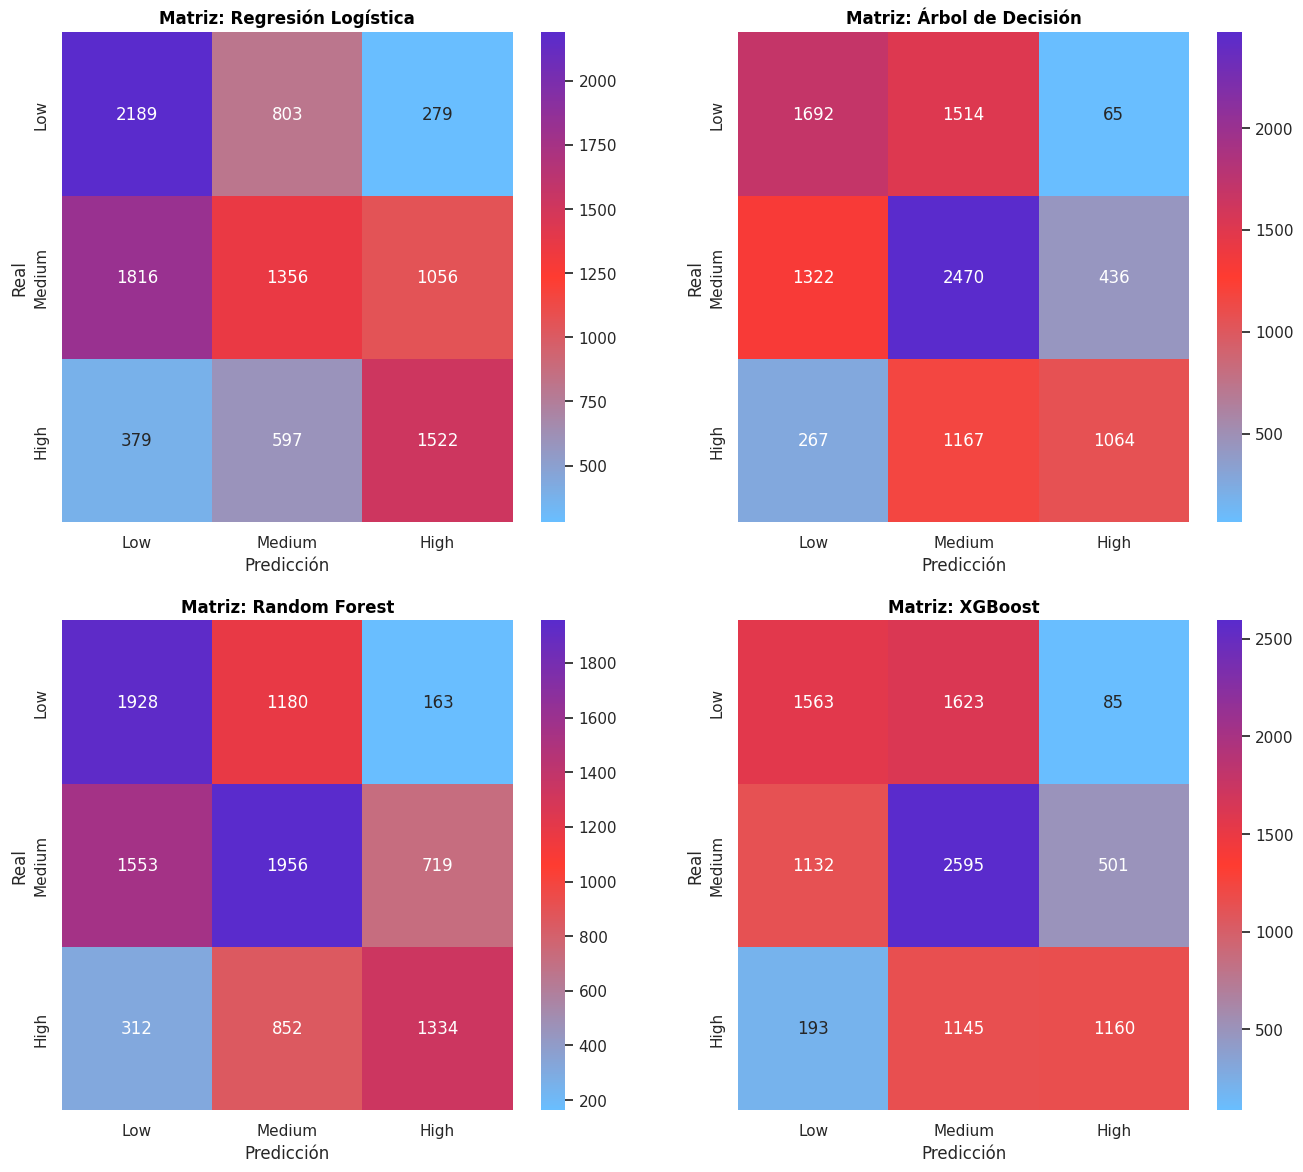

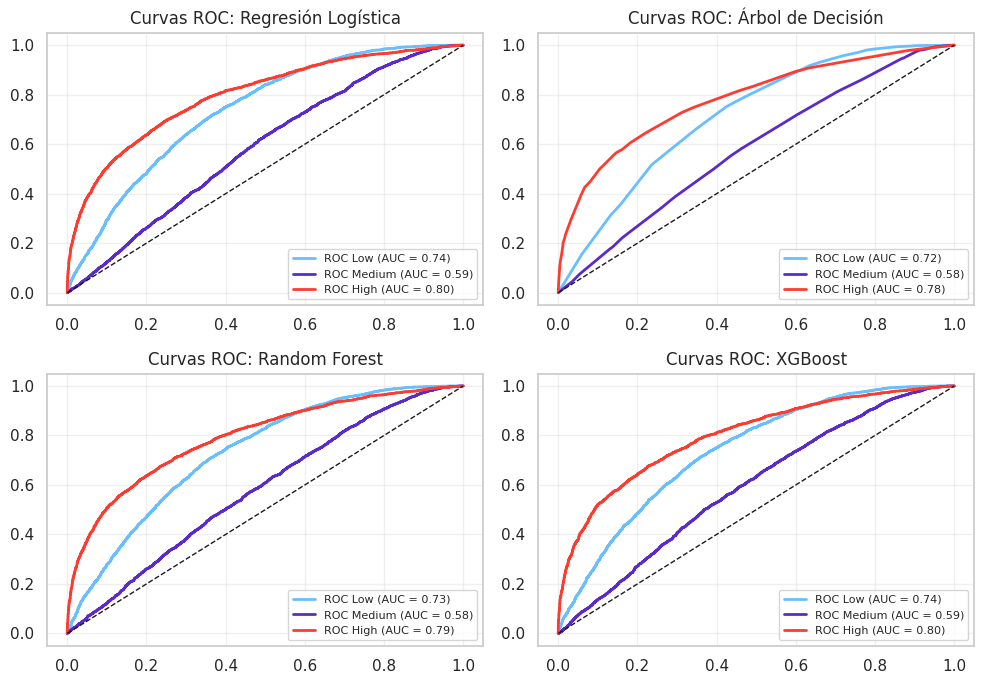

In [121]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

resultados_test = []
nombres_clases = ['Low', 'Medium', 'High']
# Binarizar etiquetas para curvas ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Preparar figura para Curvas ROC
plt.figure(figsize=(10, 7))

for i, (nombre, modelo) in enumerate(mejores_modelos.items()):
    y_pred = modelo.predict(X_test_final)
    y_proba = modelo.predict_proba(X_test_final)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1_m = f1_score(y_test, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    resultados_test.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(prec, 4),
        'Recall (Macro)': round(rec, 4),
        'F1-Macro (Test)': round(f1_m, 4),
        'ROC-AUC (OVR)': round(roc_auc, 4)
    })

    # Matriz de Confusión con paleta personalizada
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_BP, ax=axes[i],
                xticklabels=nombres_clases, yticklabels=nombres_clases)
    axes[i].set_title(f'Matriz: {nombre}', fontweight='bold', color="#000")
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicción')

    # Plot Curva ROC por modelo en un gráfico aparte
    plt.subplot(2, 2, i+1)
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        roc_auc_j = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=list(PALETTE_TARGET.values())[j], lw=2,
                 label=f'ROC {nombres_clases[j]} (AUC = {roc_auc_j:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f'Curvas ROC: {nombre}')
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
# Resumen final de evaluación
df_test_results = pd.DataFrame(resultados_test).sort_values(by='F1-Macro (Test)', ascending=False)
print("=== COMPARATIVA FINAL DE MODELOS (SET DE PRUEBA) ===")
display(df_test_results)

# Selección del ganador
mejor_modelo_nombre = df_test_results.iloc[0]['Modelo']
modelo_ganador = mejores_modelos[mejor_modelo_nombre]

print(f"\n🏆 MODELO SELECCIONADO: {mejor_modelo_nombre}")
print("Justificación: Mejor balance entre precisión y sensibilidad (F1-Macro) bajo desbalance.")

=== COMPARATIVA FINAL DE MODELOS (SET DE PRUEBA) ===


,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Macro (Test),ROC-AUC (OVR)
3,XGBoost,0.5320,0.5632,0.5187,0.5318,0.7100
2,Random Forest,0.5220,0.5336,0.5287,0.5293,0.7016
1,Árbol de Decisión,0.5228,0.5584,0.5091,0.5223,0.6936
0,Regresión Logística,0.5069,0.5080,0.5331,0.5096,0.7066



🏆 MODELO SELECCIONADO: XGBoost
Justificación: Mejor balance entre precisión y sensibilidad (F1-Macro) bajo desbalance.


### **7.1. Métricas de Clasificación Avanzadas (Modelo Ganador)**
Para el modelo seleccionado (**XGBoost**), calculamos métricas que evalúan la calidad de las probabilidades y la concordancia más allá del acierto simple.

In [123]:
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, log_loss

# Predicciones del modelo ganador
y_pred_final = modelo_ganador.predict(X_test_final)
y_proba_final = modelo_ganador.predict_proba(X_test_final)

# Cálculo de métricas adicionales
bal_acc = balanced_accuracy_score(y_test, y_pred_final)
mcc = matthews_corrcoef(y_test, y_pred_final)
loss = log_loss(y_test, y_proba_final)

print(f"--- Métricas de Clasificación Avanzadas para: {mejor_modelo_nombre} ---")
print(f"Balanced Accuracy: {bal_acc:.4f} (Promedio de recall por clase)")
print(f"Matthews Corr. Coeff (MCC): {mcc:.4f} (-1 a +1, donde +1 es perfecto)")
print(f"Log-Loss: {loss:.4f} (Penaliza la incertidumbre en predicciones incorrectas)")

--- Métricas de Clasificación Avanzadas para: XGBoost ---
Balanced Accuracy: 0.5187 (Promedio de recall por clase)
Matthews Corr. Coeff (MCC): 0.2673 (-1 a +1, donde +1 es perfecto)
Log-Loss: 0.9201 (Penaliza la incertidumbre en predicciones incorrectas)


# **8. Interpretabilidad: ¿Por qué el modelo predice Burnout?**

Utilizaremos valores SHAP para descomponer las predicciones. A diferencia de la importancia nativa, SHAP nos permite entender si una variable aumenta o disminuye el riesgo de pertenecer a una clase específica.

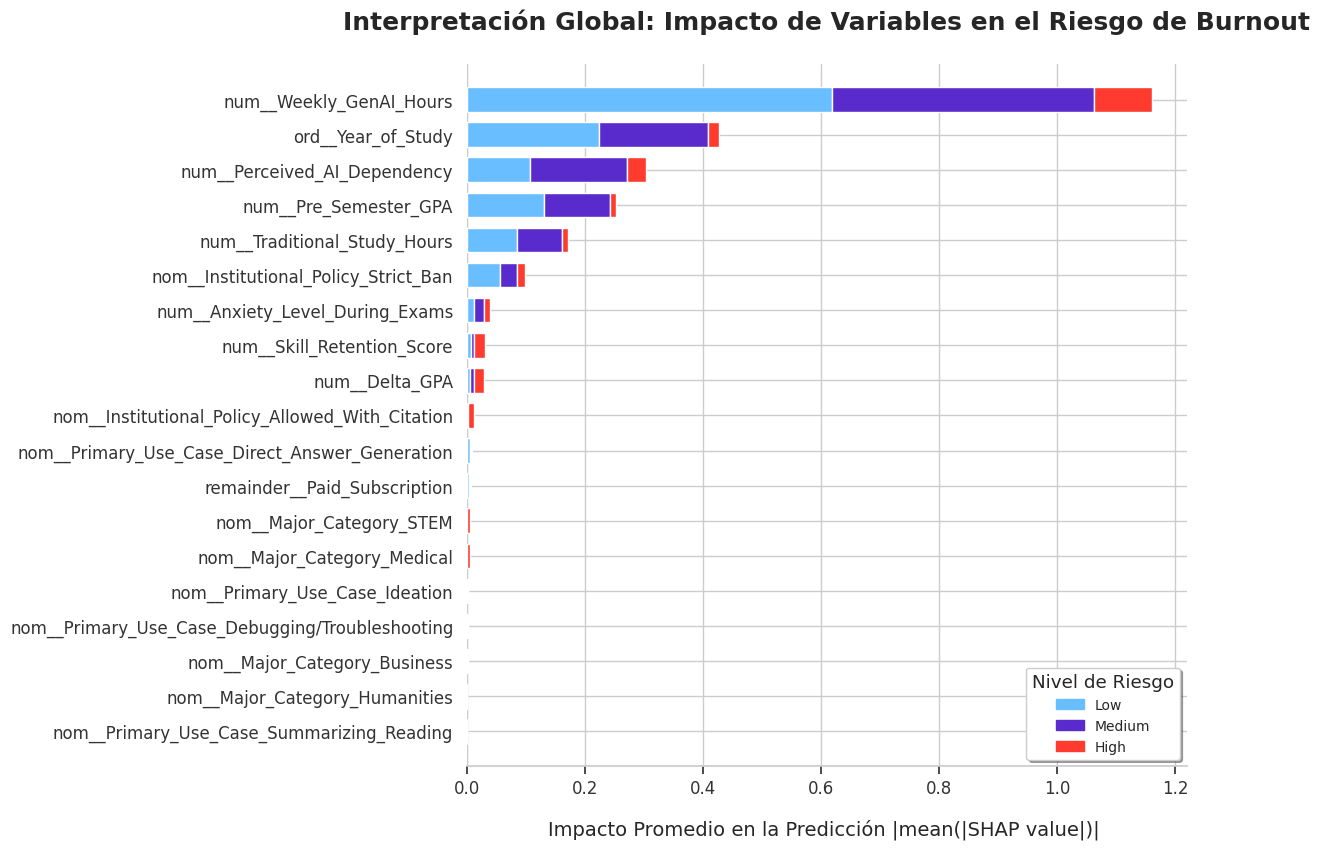

In [133]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# 1) Configuración de estilo y colores de marca
sns.set_theme(style="whitegrid", font_scale=1.1)
brand_colors = [COLOR_BLUE, COLOR_DARK, COLOR_BRICK] # Low, Medium, High
cmap_brand = ListedColormap(brand_colors)

# 2) Inicializar explicador y valores SHAP
explainer = shap.TreeExplainer(modelo_ganador)
shap_values = explainer.shap_values(X_test_final)

# 3) Generar el gráfico
# SHAP summary_plot para multiclase genera barras apiladas por defecto
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_test_final,
    class_names=nombres_clases,
    plot_type="bar",
    color=cmap_brand,
    show=False,
    plot_size=None
)

# 4) Personalización estética final
fig = plt.gcf()
ax = plt.gca()

# Título y etiquetas profesionales
ax.set_title(
    "Interpretación Global: Impacto de Variables en el Riesgo de Burnout",
    fontsize=18, fontweight="bold", pad=25
)
ax.set_xlabel(
    "Impacto Promedio en la Predicción |mean(|SHAP value|)| ",
    fontsize=14, labelpad=15
)

# Ajustar el tamaño de los ticks para legibilidad
ax.tick_params(axis='both', which='major', labelsize=12)

# Ajustar márgenes para evitar que los nombres de las variables se corten
plt.subplots_adjust(left=0.35, right=0.95, top=0.90, bottom=0.12)

# Leyenda mejorada
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=brand_colors[i], label=nombres_clases[i]) for i in range(len(nombres_clases))]
plt.legend(handles=patches, title="Nivel de Riesgo", loc='lower right', fontsize=10, shadow=True)

plt.show()

# **9. Perfilamiento Estratégico y Conclusiones**

A partir de la evidencia del modelo y el análisis SHAP, definimos los perfiles críticos para la toma de decisiones institucionales.

In [128]:
# Generación de tabla de perfiles basada en el promedio de las variables más influyentes según SHAP
vars_clave = ['Weekly_GenAI_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Pre_Semester_GPA', 'Traditional_Study_Hours']

perfiles = df_fase6.groupby('Burnout_Risk_Level')[vars_clave].mean().reindex(TARGET_ORDER)

# Añadir la categoría de carrera y año más frecuente (Moda)
perfiles['Carrera_Predominante'] = df_fase6.groupby('Burnout_Risk_Level')['Major_Category'].agg(lambda x: x.mode()[0])
perfiles['Año_Predominante'] = df_fase6.groupby('Burnout_Risk_Level')['Year_of_Study'].agg(lambda x: x.mode()[0])

print("=== MATRIZ DE PERFILAMIENTO ESTRATÉGICO ===")
display(perfiles.round(2).T)

=== MATRIZ DE PERFILAMIENTO ESTRATÉGICO ===


Burnout_Risk_Level,Low,Medium,High
Weekly_GenAI_Hours,4.65,7.35,15.21
Perceived_AI_Dependency,2.82,3.37,4.64
Anxiety_Level_During_Exams,3.93,4.17,4.89
Pre_Semester_GPA,3.2,3.14,3.08
Traditional_Study_Hours,11.97,11.29,10.08
Carrera_Predominante,STEM,STEM,STEM
Año_Predominante,Freshman,Junior,Senior


### **Descripción de Perfiles de Riesgo**

Basándonos en la tabla anterior y en la importancia de variables (donde el GPA y la dependencia de IA fueron claves), podemos definir los siguientes perfiles:

1.  **Perfil de Riesgo Alto (High):**
    *   **Comportamiento:** Presentan los niveles más altos de ansiedad y una mayor dependencia percibida de la IA.
    *   **Académico:** Suelen tener promedios (GPA) más bajos en comparación con los otros grupos.
    *   **Uso de IA:** Tienden a usar la IA para tareas de redacción o copia, lo que podría indicar una sustitución del esfuerzo cognitivo.

2.  **Perfil de Riesgo Medio (Medium):**
    *   **Comportamiento:** Niveles moderados de ansiedad y uso balanceado de herramientas.
    *   **Académico:** Promedios estables. Es el grupo mayoritario (42.2%).
    *   **Uso de IA:** Usan la IA principalmente como apoyo para resúmenes o depuración de errores.

3.  **Perfil de Riesgo Bajo (Low):**
    *   **Comportamiento:** Menor ansiedad reportada y baja dependencia de la IA.
    *   **Académico:** Poseen los promedios más altos (GPA > 3.5) y mantienen una carga alta de horas de estudio tradicional.
    *   **Uso de IA:** Utilizan la IA de forma estratégica (ideación o depuración) sin comprometer su autonomía académica.

### **Conclusiones y Recomendaciones Estratégicas para la Universidad Evaluada**

Tras el desarrollo del modelo **XGBoost** y el análisis de interpretabilidad con **SHAP**, se presentan las siguientes conclusiones clave para la institución:

1.  **El uso intensivo de IA como factor de riesgo:** El predictor más crítico no es el uso de la IA *per se*, sino la intensidad horaria (`Weekly_GenAI_Hours`) y la dependencia psicológica (`Perceived_AI_Dependency`). Los estudiantes con riesgo alto superan las 15 horas semanales de uso, lo que sugiere un desplazamiento del esfuerzo cognitivo personal.
2.  **Vulnerabilidad en Postgrado:** Contrario a la intuición inicial, los estudiantes de niveles avanzados (`Graduate`) muestran una mayor propensión al riesgo alto, posiblemente por la complejidad de sus tareas y la presión por resultados inmediatos.
3.  **La Ansiedad como Catalizador:** La fuerte asociación entre ansiedad y burnout confirma que la IA está actuando como un paliativo temporal (ayuda rápida) pero no resuelve la causa raíz del estrés académico.

**Recomendaciones:**
*   **Alfabetización Crítica en IA:** Implementar talleres no solo de 'uso' de herramientas, sino de gestión de la dependencia tecnológica.
*   **Monitoreo de Horas Críticas:** Establecer programas de bienestar específicos para estudiantes que reporten más de 12 horas semanales de uso de IA.
*   **Apoyo en Niveles Superiores:** Reforzar las tutorías académicas en los últimos años de carrera y postgrado, donde la carga académica se combina con una mayor adopción tecnológica de riesgo.